# Replica del Indice de Pobreza Laboral (PL) de INEGI/CONEVAL
El **indice de Pobreza Laboral** es un indicador que INEGI publica trimestralmente que estima el porcentaje de mexicano laboralmente activos cuyos ingresos de su empleo no son suficientes para cubrir las necesidades basicas, la metodologia de este indice es heredada de la extinta CONEVAL, INEGI practicamente usa la misma metodologia. Para la estimacion del **indice** se usan **microdatos** de la **Encuesta Nacional de Ocupacion y Empleo (ENOE)** que INEGI elebaora de manera trimestral, con la encuesta es posible replicar el indice siguiendo la metodologia

El objetivo del presente Notebook es crear una replica 1 a 1, **usando microdatos** de la **ENOE** del periodo del **2006 al 2026** comprandolo con los datos oficiales por medio de una prueba estadistica t de Student y verificar que la biblioteca Python `enoe-utilities` que se desarrollo, produce los mismos resultados para el **indice de pobreza laboral**

[Link al repositorio oficial de enoe-utilities](https://github.com/DevArmando99/enoe-utilities)

### Metadatos
```yaml
title: "Replica del Indice de Pobreza Laboral (PL) de INEGI/CONEVAL"
author: Jose Armando Carreon Montañez
version: 1.0
kernel: python3
python-version: 3.11
created: 2026-08-02
licensed: GPL v3 para este Notebook y BSD 3-Clause para enoe-utilities
```

# Introduccion
Los microdatos son la forma mas elemental de una encuesta, en el caso de la estadistica gubernamental, los microdatos son los datos "en crudo" que se recojen de las encuestas que son datos tal cual se capturaron de los encuestados. La importancia radica en que al tener los mcirodatos disponibles se pueden generar los productos estadisticos derivados siguiendo la metodologia para obtenerlo, es decir que organismos autonomos de estadisticas oficiales como INEGI, le dan certeza y creedibilidad a su trabajo, pues cualquiera con la disposion de leer la metodologuia y trabajar con microdatos puede **auditar** la informacion oficial que se comparte.
Ademas el trabajar con microdatos tambien permite obtener informacion adicional importante, segun la naturaleza de la encuesta, por ejemplo indices alternativos a los oficiales simpre que se usen de manera etica los datos, o inluso analisis exploratorios de datos para una investigacion o responder una pregunta en cuestion. 

El presente proyecto hace uso de la **Encuesta Nacional de Ocupación y Empleo (ENOE)** se define como una encuesta levantada en hogares con el objetivo obtener información estadística sobre las características ocupacionales de la población de 15 años y más a nivel nacional, así como variables demográficas y económicas para el análisis de la fuerza de trabajo, la toma de decisiones y el diseño de políticas laborales, sus principales caracteristicas son:

| Elemento | Resumen |
|----------|----------|
| **Nombre de Encuesta** | Encuesta Nacional de Ocupación y Empleo (ENOE). |
| **Abreviatura** | **ENOE** (o **ENOEN** para la Nueva Edición iniciada en 2020). |
| **Diseño estadístico** | **Probabilístico**, bietápico, estratificado y por conglomerados. |
| **Dominio de estudio** | Nacional, por entidad federativa, ciudades autorrepresentadas (39 ciudades) y por tamaños de localidad: **Urbano alto**, **Complemento urbano** y **Rural**. |
| **Unidad de observación** | **El hogar** (identificado dentro de las viviendas seleccionadas), aunque **la persona** es la unidad última de análisis. |
| **Tamaño de muestra de diseño** | Originalmente de **120,260 viviendas** (ENOE 2006-2019); la edición más reciente reporta un tamaño de **150,449 viviendas** (ENOEN/2021–2026) a nivel nacional. |
| **periodicidad** | **Trimestral** de base para todas sus variables pero tambien se ofrece adelantos **mensuales** |

Por otra parte, la **pobreza laboral** segun **CONEVAL** se define como: una situación en la que el ingreso laboral de un hogar (la suma de lo que ganan sus integrantes por su trabajo) no es suficiente para alimentar a todos sus miembros, donde **CONEVAL/INEGI** considera ue una persona está en pobreza laboral cuando el ingreso laboral per cápita de su hogar es inferior al valor monetario de la canasta alimentaria (también llamada Línea de Pobreza Extrema por Ingresos o LPEI). Mientras que el **Indice de Pobreza Laboral** segun **CONEVAL** como un indicador de corto plazo que mide el porcentaje de la población cuyo ingreso laboral per cápita es insuficiente para adquirir la canasta alimentaria.

Siguiendo la metodologia de **CONEVAL/INEGI** para el calculo del indice de porcentaje de pobreza laboral en el trimestre 't' se calcula como:

$$
PL_t =
100\,
\frac{
\sum_{i=1}^{N_t}
F_{it}\,
\mathbf{1}\!\left(
ILPC_{h(i),t}<LPEI_{a(i),t}
\right)
}{
\sum_{i=1}^{N_t}F_{it}
}
$$

El ingreso laboral per cápita de cada hogar se calcula mediante:

$$
ILPC_{h,t}
=
\frac{
\sum_{j\in h}IL_{j,t}
}{
n_{h,t}
}
$$

**Significado de los componentes**

- $PL_t$: porcentaje de la población en situación de pobreza laboral durante el trimestre $t$.

- $N_t$: número de personas observadas en la muestra de la ENOE durante el trimestre $t$.

- $IL_{j,t}$: ingreso laboral mensual de la persona $j$, identificado, estimado o imputado conforme a las reglas metodológicas aplicables.

- $n_{h,t}$: número total de integrantes del hogar $h$, independientemente de que trabajen o no.

- $ILPC_{h,t}$: ingreso laboral mensual per cápita del hogar $h$.

- $h(i)$: hogar al que pertenece la persona $i$.

- $LPEI_{a(i),t}$: valor de la Línea de Pobreza Extrema por Ingresos aplicable a la persona $i$, de acuerdo con el ámbito de residencia de su hogar:
  - rural;
  - urbano.

- $F_{it}$: factor de expansión correspondiente a la persona $i$ en la ENOE.

- $\mathbf{1}(\cdot)$: función indicadora que asigna el valor 1 cuando se cumple la condición y 0 cuando no se cumple:

$$
\mathbf{1}\!\left(
ILPC_{h(i),t}<LPEI_{a(i),t}
\right)
=
\begin{cases}
1, & \text{si el ingreso laboral per cápita del hogar es inferior a la LPEI},\\
0, & \text{en caso contrario}.
\end{cases}
$$

Para cada hogar se identifican y suman los ingresos laborales mensuales de sus integrantes, aplicando previamente las reglas metodológicas correspondientes para recuperar, estimar o imputar dichos ingresos.

No se suman simplemente los ingresos de todas las personas económicamente activas. Se consideran específicamente los ingresos laborales de las personas ocupadas que cumplen los criterios metodológicos. Una persona desocupada puede formar parte de la población económicamente activa, pero no aporta ingreso laboral; sin embargo, sí cuenta como integrante del hogar.

El ingreso laboral total del hogar se divide entre el número total de integrantes del hogar, incluyendo:

- personas ocupadas;
- personas desocupadas;
- personas económicamente inactivas;
- niñas, niños y otros menores de edad;
- integrantes que no reciben ingresos laborales.

El resultado de esta división es el ingreso laboral per cápita del hogar:

$$
\text{Ingreso laboral per cápita del hogar}
=
\frac{
\text{Ingreso laboral total mensual del hogar}
}{
\text{Número total de integrantes del hogar}
}
$$

Posteriormente, el ingreso laboral per cápita se compara con la Línea de Pobreza Extrema por Ingresos correspondiente al ámbito de residencia del hogar.

No se obtiene una media entre la línea rural y la urbana. A cada hogar se le aplica exclusivamente la línea que le corresponde:

- LPEI rural, si el hogar pertenece al ámbito rural.
- LPEI urbana, si el hogar pertenece al ámbito urbano.

Si la implementación trimestral utiliza el promedio de los tres valores mensuales de la línea correspondiente, este puede expresarse como:

$$
\overline{LPEI}_{a,t}
=
\frac{
LPEI_{a,m_1}
+
LPEI_{a,m_2}
+
LPEI_{a,m_3}
}{3}
$$

donde $a$ representa el ámbito rural o urbano, pero sin mezclar ambos tipos de línea.

Cuando el ingreso laboral per cápita del hogar es inferior a la LPEI correspondiente, todos los integrantes de ese hogar se clasifican como población en pobreza laboral.

Finalmente, se suman los factores de expansión de todas las personas que pertenecen a hogares clasificados en pobreza laboral. Esta cantidad se divide entre la suma de los factores de expansión de todas las personas y el resultado se multiplica por 100.

En términos sencillos:

$$
\text{Porcentaje de pobreza laboral}
=
100
\times
\frac{
\text{Población expandida perteneciente a hogares bajo la LPEI}
}{
\text{Población total expandida}
}
$$

Por tanto, el indicador mide un porcentaje de personas, no un porcentaje de hogares.

**Forma equivalente calculada por hogares**

Debido a que todos los integrantes de un hogar reciben la misma clasificación, la fórmula también puede representarse por hogares:

$$
PL_t=
100\,
\frac{
\sum_{h=1}^{H_t}
F_{ht}\,n_{ht}\,
\mathbf{1}\!\left(
ILPC_{h,t}<LPEI_{a(h),t}
\right)
}{
\sum_{h=1}^{H_t}
F_{ht}\,n_{ht}
}
$$

donde:

- $H_t$: número de hogares observados en el trimestre $t$.
- $F_{ht}$: factor de expansión asociado al hogar $h$.
- $n_{ht}$: número de integrantes del hogar.
- $F_{ht}n_{ht}$: cantidad de personas expandidas representadas por el hogar.

No sería correcto calcular solamente:

$$
\frac{
\sum F_h\text{ de los hogares pobres}
}{
\sum F_h\text{ de todos los hogares}
}
$$

porque ese cociente representaría un porcentaje de hogares. Para calcular el porcentaje oficial de población en pobreza laboral es necesario ponderar también por el número de integrantes:

$$
F_{ht}\times n_{ht}
$$

En forma resumida, el procedimiento es:

1. Calcular el ingreso laboral mensual de cada persona conforme a las reglas metodológicas.
2. Sumar los ingresos laborales de todos los integrantes de cada hogar.
3. Dividir el ingreso laboral total entre el número total de integrantes del hogar.
4. Comparar el ingreso laboral per cápita con la LPEI rural o urbana aplicable.
5. Clasificar a todos los integrantes de los hogares situados por debajo del umbral como población en pobreza laboral.
6. Sumar los factores de expansión de esas personas.
7. Dividir esa población expandida entre la población total expandida.
8. Multiplicar el resultado por 100.

**Diferencia respecto del ITLP**

El porcentaje de pobreza laboral no debe confundirse con el Índice de la Tendencia Laboral de la Pobreza. De manera simplificada, el ITLP compara la incidencia de pobreza laboral de un periodo con la de un periodo base:

$$
ITLP_t
=
\frac{
PL_t
}{
PL_{\text{periodo base}}
}
$$

El porcentaje de pobreza laboral mide directamente la proporción expandida de la población que se encuentra en pobreza laboral, mientras que el ITLP expresa su evolución respecto de un periodo base.


# Descripcion de la hipotesis
El presente Notobook se basa en las siguientes preguntas:
- ¿Es posible recrear el porcentaje del **indice de pobreza** de INEGI/CONEVAL siguiendo las metodologia de ENOE y las de CONEVAL? Si sí
- ¿La herramienta metodologica (biblioteca `enoe-utilities`) producce los mismo resultados?
- y por extension de la segunda pregunta, al desarrollar 2 decadas de **indice de pobreza** en forma de auditoria de integridad de datos ¿Las cifras oficiales coinciden con lo esperado segun su descripcion en las metodologias que siguen?

# Fuentes primarias de inforcion:
El presente Notebook no representa informacion oficial de INEGI ni sustituye las metodologias oficiales aplicadas, por ello se recomeinda consultar las fuentes oficiales:
[(Indice) Pobreza Laboral](https://www.inegi.org.mx/desarrollosocial/pl/) Aqui se encuentra los datos oficiales del instituto asi como su metodologia
[Metodologia de Indice de Pobreza Laboral CONEVAL](https://www.coneval.org.mx/Medicion/Documents/ITLP_IS/Nota_imputacion_ingresos_laborales_CONEVAL.pdf)
[Lineas de Pobreza oficial](https://www.inegi.org.mx/desarrollosocial/lp/)

Para descargar e isntalar la biblioteca python `enoe-utilities` asi como su wiki operativa oficial dirigirse al repositorio oficial [enoe-utilities](https://github.com/DevArmando99/enoe-utilities)

Para la documentacion sobre su desarrollo, decisiones que se tomaron por favor consultar su documentacion de leaboracion en Notion [documentacion de desarrollo](https://documetation2.notion.site/Biblioteca-reproducible-para-el-procesamiento-de-ENOE-y-c-lculo-de-pobreza-laboral-3afed0caa1fd8027a0f0f9391e9aeaf8)

# Descripcion integral general del proyecto.
El presente Notebook conforma parte del proyecto integral del uso y trabajo con microdatos de la ENOE, este Notebook representa parte del proyecto total donde el objetivo de este Notebook es la parte de demostrar capacidad de abstraccion de metodologias oficiales, creaccion de herramientas en Python para tyrabajar con microdatos, y replicar indicies (productos) estadisticos a partir de microdatos. Los proyectos que conforman el proyecto general son:

```mermaid
flowchart TD
    A["Uso de microdatos de ENOE para generar indices y exploracion de datos"] --> B["1. Biblioteca de procesamiento"]
    A --> C["2. Replicación del indicador porcentaje de pobreza laboral"]
    A --> D["3. Índice alternativo alternativo de pobreza laboral"]
    A --> E["4. Hallazgos socioeconómicos"]
```

# Descargo de responsabilidades

Este proyecto es una iniciativa personal, independiente y de carácter académico, técnico y exploratorio. Su desarrollo no constituye una actividad, publicación, producto, encargo o comunicación oficial del Instituto Nacional de Estadística y Geografía (INEGI).

Todas las metodologías, documentos técnicos, tabulados, catálogos, cuestionarios y microdatos utilizados fueron obtenidos exclusivamente mediante los canales públicos y oficiales de consulta, documentación y descarga del INEGI. El proyecto no utiliza información confidencial, reservada, privilegiada, no publicada ni obtenida mediante accesos internos del Instituto.

Los resultados, indicadores, cálculos, interpretaciones, visualizaciones, errores, omisiones y conclusiones que se presenten son responsabilidad exclusiva del autor. No representan la postura, opinión, validación, metodología oficial ni resultados oficiales del INEGI, del CONEVAL o de cualquier otra institución pública. Cuando se reproduzcan indicadores oficiales, se señalarán expresamente su fuente, periodo y metodología de referencia.

Aunque el autor presta servicios en el INEGI, este proyecto fue desarrollado a título estrictamente personal:

* fuera del horario laboral;
* sin utilizar equipos, cuentas, sistemas, licencias, instalaciones, redes, servicios de cómputo ni otros recursos institucionales;
* sin emplear información conocida con motivo del cargo que tenga carácter confidencial, reservado, restringido o no público;
* sin utilizar atribuciones, representación, logotipos o canales institucionales;
* sin solicitar ni recibir instrucciones, apoyo, validación o autorización institucional para presentar los resultados como oficiales; y
* sin interferir con las funciones, responsabilidades u obligaciones laborales del autor.

En consecuencia, la referencia a la calidad de trabajador del INEGI tiene únicamente fines de transparencia y no implica participación, respaldo, patrocinio, revisión o aprobación institucional.

El proyecto se realiza, según el conocimiento y las circunstancias declaradas por el autor, procurando observar la legislación aplicable, las obligaciones del servicio público, los principios de integridad, la confidencialidad estadística, la protección de datos y las disposiciones institucionales correspondientes. Este texto no constituye una opinión jurídica ni sustituye una consulta ante las instancias competentes del INEGI.

El uso de este proyecto, su código y sus resultados debe realizarse con criterio técnico y bajo responsabilidad de cada persona usuaria. Antes de emplear sus resultados para decisiones públicas, administrativas, jurídicas, financieras o de política social, deberán contrastarse con las publicaciones, metodologías e indicadores oficiales vigentes.

**Fuente de los datos:** Instituto Nacional de Estadística y Geografía, mediante sus portales y canales oficiales de consulta y descarga.

**Carácter del proyecto:** personal, independiente, no oficial y sin afiliación institucional.


# Configuracion de dependencias, descripcion de datos y preparacion de datos

In [1]:
# Bibliotecas a usar
import enoe_utilities
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from openpyxl import load_workbook
from enoe_utilities import (
    get_time_series,
    get_pl_series,
    build_lpei_quarterly_long,
    validate_required_columns,
    build_merged_time_series,
    validate_merged_period,
    build_analysis_dataset,
    compute_pl_time_series,
    build_historical_analysis_parquet,
)

## Descripcion de las tablas y encuestas de la ENOE
En la ENOE existen 5 encuestas distintas que preguntan al encuesta una serie de informacion socioeconomica, estas encuestas se recopilan sus respuestas en 5 datasets distintos y esos datos "en crudo" se le conoce como microdatos, naturalmente no todas las encuestas que en la encuesta ENOE se realiza se utilizaran, para replicar el indice de pobreza laboral se seleccionan de solamente dos: `SDEM` y `COE2`. 

**SDEM**
SDEM es la tabla sociodemográfica a nivel de persona. Contiene a los integrantes de los hogares entrevistados, los identificadores de vivienda, hogar y persona, el resultado de entrevista, la residencia habitual, parentesco, sexo, edad, escolaridad y otras características demográficas. También incorpora variables precodificadas derivadas del Cuestionario de Ocupación y Empleo, así como factores de expansión.

El descriptor histórico del INEGI explica que SDEM conserva la información del cuestionario sociodemográfico y sirve como tabla central para relacionar las demás tablas de la ENOE. El  confirma que incluye a todos los integrantes del hogar y que muchas variables laborales son precodificadas, no preguntas directas.

El cuestionario sociodemográfico no ha mantenido un número fijo de preguntas:

| Versión representativa | Preguntas | Enfoque |
|---|---:|---|
| Cuestionario sociodemográfico inicial, 2005–2006 | 23 | Residentes, parentesco, sexo, edad, fecha y lugar de nacimiento, escolaridad, hijos, estado conyugal y características básicas del hogar |
| Cuestionario sociodemográfico vigente documentado en 2024–2025 | 26 | Conserva el núcleo anterior e incorpora la organización y redacción de la edición actual, además de observaciones e identificación del informante |

**COE2**
COE2 es la segunda tabla del Cuestionario de Ocupación y Empleo. Por razones de tamaño, el INEGI distribuye el COE en COE1 y COE2:

- COE1 almacena el comienzo del cuestionario, principalmente las preguntas 1 a 5.
- COE2 almacena las preguntas 6 a 9 de la versión básica y 6 a 11 de la versión ampliada, además de identificadores y variables de apoyo.

Su foco principal es profundizar en las características del trabajo: forma de pago, ingreso laboral, jornada, prestaciones, búsqueda o antecedentes laborales y, en el cuestionario ampliado, apoyos y otras actividades. Para pobreza laboral, la biblioteca necesita específicamente cuatro variables de la pregunta 6: ausencia de pago, frecuencia de pago, monto exacto y rango de ingreso en salarios mínimos.

El número publicado por INEGI corresponde al **COE completo**, no exclusivamente a COE2, y cambia según la edición:

| Etapa o versión representativa | COE básico completo | COE ampliado completo | Qué conserva COE2 |
|---|---:|---:|---|
| ENOE inicial, 2006–2007 | 62 preguntas en 9 baterías | 90 preguntas en 11 baterías | Segunda parte: preguntas 6–9 o 6–11 |
| ENOEN, versión 2021 | 60 preguntas en la versión básica | 90 preguntas en la ampliada | Segunda parte del cuestionario de nueva edición |
| ENOE regular, edición documentada 2023–2025 | 65 preguntas en 9 baterías | 95 preguntas en 11 baterías | Segunda parte del cuestionario vigente |

**Diccionario de tablas**
Para todo el periodo analizado, del **2006** al **2026**, en _COE2_ tiene 166 columnas unicas y en _SDEM_ tiene 125, sin embargo no se utilizan todas, para distintos años se usan equivalentes y agrupando las equivalencias entre columnas, se tiene que los parquet tienen las siguienetes columnas de interes:


**SDEM**

Nota: En la columna **Unidades**, “sin unidad” significa que el dato es un identificador o una categoría y no una magnitud física o monetaria. Los códigos y rangos se resumen para facilitar el uso; para una explotación distinta a la biblioteca debe consultarse el catálogo específico del trimestre.

| Columnas | Descripción | Unidades | Notas |
|---|---|---|---|
| `cd_a` | Código de ciudad autorrepresentada o dominio urbano utilizado por el diseño de la encuesta. | Código geográfico; sin unidad | Forma parte de la llave. El mnemónico se conserva en los periodos revisados. No debe interpretarse como el nombre de una ciudad. |
| `cve_ent` / `ent` | Clave de la entidad federativa donde se ubica la vivienda seleccionada. | Código INEGI de entidad; sin unidad | `ent` se usa de 2006T1 a 2025T2; `cve_ent` desde 2025T3. La biblioteca normaliza ambos como `cve_ent`. |
| `con` | Número de control operativo asignado al conjunto de viviendas de la muestra. | Identificador; sin unidad | Parte de la llave. Debe preservarse como texto para no perder ceros a la izquierda. |
| `upm` | Clave de la Unidad Primaria de Muestreo. | Identificador muestral; sin unidad | Parte de la llave y del diseño de selección. No es un conteo de UPM. |
| `d_sem` | Distribución semanal asignada al levantamiento. | Código operativo; sin unidad | Parte de la llave histórica. Identifica la distribución o panel semanal; debe preservarse como código. |
| `n_pro_viv` | Número progresivo de la vivienda en el listado de la UPM. | Identificador de vivienda; sin unidad | Parte de la llave. No representa el total de viviendas. |
| `v_sel` | Número de vivienda seleccionada dentro del control o listado. | Identificador ordinal; sin unidad | Parte de la llave de vivienda y persona. |
| `n_hog` | Número del hogar dentro de la vivienda seleccionada. | Identificador de hogar; sin unidad | Permite distinguir más de un hogar en una vivienda. Forma parte de las llaves de hogar y persona. |
| `h_mud` | Número de veces que el hogar registrado se mudó durante el seguimiento. | Veces | Parte de la llave longitudinal. Los descriptores codifican normalmente 0–4; no es un indicador de migración individual. |
| `n_ent` | Número de entrevista o visita del hogar en el esquema rotatorio. | Entrevista, valor ordinal 1–5 | Cada vivienda permanece hasta cinco entrevistas a lo largo de cinco trimestres. Parte de la llave. |
| `per` | Periodo de levantamiento contenido en el archivo. | Código de trimestre y año | En los archivos históricos se representa como trimestre seguido de dos dígitos de año, por ejemplo `407` para 2007T4. Parte de la llave y distinto de la columna técnica `periodo`. |
| `n_ren` | Número de renglón asignado a la persona dentro del hogar. | Identificador de persona; sin unidad | Completa la llave de persona; se excluye de la llave de hogar. No equivale al total de residentes. |
| `r_def` | Resultado definitivo de la entrevista del hogar. | Categoría codificada; sin unidad | `00` identifica entrevista completa. El dataset analítico conserva `r_def == 0` tras la normalización numérica. |
| `c_res` | Condición de residencia de la persona en el hogar. | Categoría codificada; sin unidad | Códigos centrales: 1 residente habitual, 2 ausente definitivo, 3 nuevo residente. La biblioteca conserva 1 y 3. |
| `par_c` | Parentesco de la persona con la jefatura del hogar. | Código de catálogo; sin unidad | El mnemónico se conserva, pero el catálogo de parentesco ha tenido actualizaciones; el descriptor vigente señala una clasificación aplicable desde 2021T3. Es clave para agregaciones y perfiles de hogar, no para la unión física. |
| `sex` | Sexo registrado de la persona. | Categoría: 1 hombre, 2 mujer | El archivo conserva la codificación estadística del cuestionario; no es una unidad de medida. |
| `eda` | Edad de la persona. | Años cumplidos | Incluye códigos especiales: 00 para menor de un año, 97 para 97 o más y códigos de no especificado en algunos descriptores. Para análisis debe distinguirse edad de códigos especiales. |
| `n_hij` | Número total de hijas e hijos nacidos vivos declarado en el módulo sociodemográfico. | Personas, conteo | 00 significa ninguno; existen códigos de no especificado. La pregunta aplica según el universo definido por el cuestionario. |
| `e_con` | Estado conyugal de la persona. | Categoría codificada; sin unidad | Distingue unión libre, separación, divorcio, viudez, matrimonio y soltería, además de no especificado. |
| `t_loc_tri` / `t_loc` | Tamaño de localidad usado para clasificación trimestral. | Categoría por rango de habitantes | `t_loc` hasta ENOE 2020T1; `t_loc_tri` desde ENOEN 2020T3. En el descriptor vigente: 1 = 100 mil o más; 2 = 15 mil–99,999; 3 = 2,500–14,999; 4 = menos de 2,500. La biblioteca lo usa para asignar ámbito urbano/rural. |
| `clase2` | Clasificación precodificada de la condición de actividad en segunda categoría. | Categoría codificada; sin unidad | Distingue 1 ocupada, 2 desocupada, 3 disponible y 4 no disponible. No es una pregunta directa; deriva de la secuencia del COE. |
| `pos_ocu` | Posición en la ocupación de las personas ocupadas. | Categoría codificada; sin unidad | Distingue subordinado remunerado, empleador, cuenta propia, trabajador sin pago y no especificado. La biblioteca la usa junto con `p6_9` para reconocer trabajo no remunerado. |
| `salario` | Salario mínimo mensualizado de referencia asociado al periodo y, cuando corresponde, a la zona salarial. | Pesos mexicanos corrientes por mes | Variable de apoyo, no ingreso observado de la persona. La biblioteca la utiliza para convertir el rango de `p6c` en un ingreso recuperado. |
| `fac_tri` / `fac` | Factor de expansión trimestral de la persona. | Personas representadas por registro muestral | `fac` hasta ENOE 2020T1; `fac_tri` desde ENOEN 2020T3. La biblioteca normaliza a `fac_tri` y lo toma de SDEM. No debe sustituirse por `fac_men`. |



**COE2**

Nota: Las primeras doce columnas son copias de identificadores que permiten relacionar COE2 con SDEM; no provienen de preguntas del COE2. Las cuatro últimas sí corresponden a la pregunta 6 del cuestionario.
| Columnas | Descripción | Unidades | Notas |
|---|---|---|---|
| `cd_a` | Código de ciudad autorrepresentada o dominio urbano. | Código geográfico; sin unidad | Campo de enlace copiado de los identificadores de la encuesta; el mnemónico se conserva. |
| `cve_ent` / `ent` | Clave de entidad federativa de la vivienda seleccionada. | Código INEGI de entidad; sin unidad | `ent` hasta 2025T2 y `cve_ent` desde 2025T3. Se normaliza a `cve_ent` antes de unir. |
| `con` | Número de control operativo de la vivienda. | Identificador; sin unidad | Parte de la llave; debe tratarse como texto. |
| `upm` | Clave de Unidad Primaria de Muestreo. | Identificador muestral; sin unidad | Parte de la llave, no una respuesta del COE. |
| `d_sem` | Distribución semanal del levantamiento. | Código operativo; sin unidad | Parte de la llave; se copia para mantener la identificación completa. |
| `n_pro_viv` | Número progresivo de la vivienda. | Identificador de vivienda; sin unidad | Parte de la llave de persona. |
| `v_sel` | Número de vivienda seleccionada. | Identificador ordinal; sin unidad | Parte de la llave. |
| `n_hog` | Número de hogar dentro de la vivienda. | Identificador de hogar; sin unidad | Parte de las llaves de hogar y persona. |
| `h_mud` | Número de mudanzas del hogar durante su seguimiento. | Veces | Parte de la llave longitudinal y no una pregunta laboral de COE2. |
| `n_ent` | Número de entrevista dentro del panel rotatorio. | Entrevista, valor ordinal 1–5 | Parte de la llave. |
| `per` | Periodo trimestral contenido en el archivo. | Código de trimestre y año | Parte de la llave; la biblioteca crea además `periodo` en formato legible. |
| `n_ren` | Renglón de la persona dentro del hogar. | Identificador de persona; sin unidad | Completa la llave persona. El diccionario histórico indica que se copia desde SDEM. |
| `p6_9` | Opción de la pregunta 6 que identifica trabajo sin pago o ausencia de ingresos, incluido el autoconsumo agropecuario previsto por el cuestionario. | Indicador categórico; sin unidad | Se registra normalmente con la opción 9 o queda en blanco cuando no aplica. La biblioteca lo usa junto con `pos_ocu` para fijar ingreso laboral igual a cero en trabajadores sin pago. |
| `p6b1` | Periodicidad con la que la persona recibe o declara el ingreso de su trabajo principal. | Categoría de frecuencia de pago | Incluye mes, quincena, semana, día, otro periodo y pago por pieza/servicio, además de no respuesta. Es indispensable para expresar `p6b2` en términos mensuales. |
| `p6b2` | Monto exacto declarado por el trabajo principal para la periodicidad indicada en `p6b1`. | Pesos mexicanos corrientes por periodo de pago declarado | No es necesariamente mensual en el archivo fuente. El pipeline da prioridad a este monto y lo mensualiza según `p6b1`. Los códigos de desconocimiento o rechazo no son montos válidos. |
| `p6c` | Rango del ingreso del trabajo principal expresado en intervalos de salarios mínimos. | Categoría en múltiplos del salario mínimo mensual | Se utiliza cuando no existe un monto exacto recuperable. Los rangos oficiales cubren menos de uno, uno, más de 1–2, más de 2–3, más de 3–5, más de 5–10 y más de 10 salarios mínimos, además de rechazo o desconocimiento. |


**Referencias enlazadas**


- **ENOE (principal):** <https://www.inegi.org.mx/programas/enoe/15ymas/>
- **Pobreza Laboral (PL):** <https://www.inegi.org.mx/desarrollosocial/pl/>
- **Línea de Pobreza (LP):** <https://www.inegi.org.mx/desarrollosocial/datos

- **Guía de bases de datos:** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymas/doc/con_basedatos_proy2010.pdf>
- **Notas sobre microdatos:** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymas/doc/enoe_notas_microde archivos

- **Estructura (legado):** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymas/doc/fd_c_bas_amp_15ymas.pdf>
- **Estructura ENOEN (2020–2021):** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymas/doc/enoe_n_fd_c_bas_amp.pdf>
- **Estructura actual:** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymas/doc/enoe_325_fds de Diccionarios de datos (RNM): datos (RNM)

- **SDEM 2006:** <https://www.inegi.org.mx/rnm/index.php/catalog/1076/data-dictionary/F14?file_Diccionarios de datos (RNM): name=SDEMT106>
- **COE2 2006:** <https://www.inegi.org.mx/rnm/index.php/catalog/1076/ios sociodemográficos

- **Cuestionario sociodemográfico (versión antigua):** <https://www.inegi.org.mx/contenidos/programas/enoe/15ymasCuestionarios sociodemográficos: /doc/c_sdem_v1.pdf>
- **Materiales relacionados (actual):** <https://www.inegi.org.mx/rnm/index.php/catalog/1016/related-materials>
- **Cuestionario sociodemográfico (actual):** <https://www.inegi.org.mx/contenidos/programas/enoe/
- **Catálogos RNM de microdatos: ENOE básica 2006:** <https://www.inegi.org.mx/rnm/index.php/catalog/1077>
- **Catálogos RNM de microdatos: ENOE ampliada 2007:** <https://www.inegi.org.mx/rnm/index.php/catalog/1056>
- **Catálogos RNM de microdatos: ENOEN 2021:** <https://www.inegi.org.mx/rnm/index.php/catalog/710>
- **Catálogos RNM de microdatos: ENOE 2024:** <https://www.inegi.org.mx/rnm/index.php/catalog/1016>
- **Catálogos RNM de microdatos: ENOE 2025:** <https://www.inegi.org.mx/rnm/index.php/catalog/1121>.org.mx/rnm/index.php/catalog/1121>


## Preparacion de datos
Los datos 
Los datos fueron recuperados de la pagina oficial de INEGI de la ENOE ([Microdatos](https://www.inegi.org.mx/programas/enoe/15ymas/#microdatos)), para el perido de 2006 al 2026. Los microdatos vienen en archivos .zip que dentro de cada uno de ellos viene 5 archivos `.csv` uno por cada cuestionario de la ENOE, en total se descargaron 80 archivos .zip, para el proyecto solo se utilizan los archivos `.csv` de las tablas `COE2` y `SDEM`.

Los `.zip`se guardan en la carpeta `zip` del proyecto, se define tambien las rutas de salida de los archivo `parquet` y de los metadatos y paradatos. Los metadatos contienen informacion de indicadores calidad de datos, en formato JSON, mientras que los paradatos contienen logs y mensajes de la biblioteca `enoe_utilities` durante el procesamiento de datos.

Los indicadores de calidad de datos miden tasas de cruce de informacion, porcentaje de nulos, porcentaje de imputaciones entre otros, para mayor informacio vease wiki canonica de la biblioteca en [GitHub](https://github.com/DevArmando99/enoe-utilities/wiki)

Teniendo definidas rutas de entardas y salidas, se procede a usar la funcion `get_time_series()` para pasar del archivo .zip crudo de INEGI a parquets crudos de las tablas `COE2` y `SDEM`, en automatico la funcion escanea toda la carpeta donde estan los ZIP y extrae solo las tablas necesarias para calcular el indide de pobreza.

In [3]:
# Rutas
project_root = Path.cwd() # Ruta raiz del proyecto
raw_data = project_root / "data" / "raw" / "zip" # Datos .zip descargados de INEGI
raw_lpei = project_root / "data" / "raw" / "lpei" # Dato .csv de linea de pobreza
out_parquet = project_root / "data" / "parquet" / "converted" # Ruta de salida de parquet transformados
out_metadata = project_root / "outputs" / "metadata" # Ruta de salida de metadatos
out_paradata = project_root / "outputs" / "paradata" # Ruta de salida de paradatos


#  Carga de datos
raw_time_series = get_time_series(
    path_in=raw_data,
    path_out=out_parquet,
    generate_metadata=True,
    path_paradata=out_paradata,
)



Procesando 2006T1: 2006trim1_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2006T2: 2006trim2_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2006T3: 2006trim3_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2006T4: 2006trim4_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2007T1: 2007trim1_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2007T2: 2007trim2_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2007T3: 2007trim3_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.parquet

Procesando 2007T4: 2007trim4_csv.zip
  COE2: ya existe, se conserva COE2.parquet
  SDEM: ya existe, se conserva SDEM.

## Exploración de columnas y selección de llaves canónicas

Una vez convertidos los archivos CSV de SDEM y COE2 a formato Parquet, se realizó una exploración conjunta de las columnas presentes en los distintos periodos de la ENOE y la ENOEN comprendidos entre 2006 y 2026. El objetivo fue identificar el esquema histórico de cada tabla, detectar variables que desaparecieron, se incorporaron o cambiaron de nombre, y establecer un conjunto de nombres canónicos que permitiera procesar todos los periodos mediante una misma lógica.

La exploración no consistió únicamente en obtener la unión de los nombres de columnas. También se comparó la estructura de los archivos, la presencia de variables críticas, su disponibilidad en cada periodo y su función dentro del procesamiento. Este procedimiento permitió detectar equivalencias históricas como `ent` y `cve_ent`, `t_loc` y `t_loc_tri`, así como `fac` y `fac_tri`. Para evitar que estas diferencias impidieran la integración histórica, los nombres antiguos se homologaron internamente a los nombres canónicos actuales:

| Nombre histórico | Nombre canónico | Función                               |
| ---------------- | --------------- | ------------------------------------- |
| `ent`            | `cve_ent`       | Identificador de entidad federativa   |
| `t_loc`          | `t_loc_tri`     | Tamaño o tipo de localidad trimestral |
| `fac`            | `fac_tri`       | Factor de expansión trimestral        |

También se incorporó una limpieza de caracteres BOM que, en algunos archivos, provocaba que columnas como `cd_a` o `r_def` fueran leídas incorrectamente como `ï»¿cd_a` o `ï»¿r_def`. Esta normalización fue necesaria para que la validación de columnas y las operaciones posteriores utilizaran nombres consistentes.

### Selección de las llaves identificadoras

La selección de las llaves se realizó considerando la estructura jerárquica de los microdatos: vivienda, hogar y persona. Las variables seleccionadas debían permitir identificar de forma estable una observación dentro de cada periodo y conservar la correspondencia entre SDEM y COE2.

La identificación conceptual se definió de la siguiente manera:

* **Vivienda:** `cd_a`, `cve_ent`, `con`, `n_pro_viv`, `v_sel` y `n_ent`.
* **Hogar:** llave de vivienda más `n_hog` y `h_mud`.
* **Persona:** llave de hogar más `n_ren`.

Por tanto, la `HOUSEHOLD_KEY` se construyó excluyendo el número de renglón de la persona, mientras que la `PERSON_KEY` incorporó `n_ren`, que identifica a la persona dentro del hogar:

```python
HOUSEHOLD_KEY = [
    "cd_a", "cve_ent", "con", "n_pro_viv",
    "v_sel", "n_ent", "n_hog", "h_mud"
]

PERSON_KEY = [
    "cd_a", "cve_ent", "con", "upm", "d_sem",
    "n_pro_viv", "v_sel", "n_hog", "h_mud",
    "n_ent", "per", "n_ren"
]
```

La llave de persona fue seleccionada como llave principal para integrar SDEM y COE2, ya que ambas tablas contienen información referida al mismo renglón de persona. SDEM funciona como tabla madre porque contiene el universo de personas entrevistadas, mientras que COE2 aporta información adicional, principalmente relacionada con la condición de actividad, ocupación e ingresos laborales. En consecuencia, se utiliza una unión `LEFT JOIN` conservando todas las observaciones de SDEM, aunque algunas personas no tengan un registro correspondiente en COE2.

La ausencia de coincidencia no se interpreta automáticamente como un error. COE2 no contiene necesariamente información laboral para todas las personas de SDEM, por lo que la cobertura del cruce puede ser inferior al 100 %. La evaluación debe concentrarse especialmente en que las personas ocupadas y elegibles para el cálculo de ingreso laboral tengan la correspondencia esperada.

Finalmente, estas llaves son únicas dentro de cada periodo de levantamiento, pero no deben considerarse identificadores permanentes de una persona a lo largo de toda la serie histórica. Algunos identificadores pueden reutilizarse en distintos trimestres; por ello, el periodo debe conservarse como parte del contexto de la observación o como partición del conjunto de datos. De esta manera, la biblioteca puede distinguir correctamente entre una misma combinación de identificadores observada en diferentes trimestres y garantizar que la integración histórica no genere duplicados artificiales.


In [5]:
def limpiar_nombre_columna(nombre):
    return (
        str(nombre)
        .replace("\ufeff", "")  # BOM real
        .replace("ï»¿", "")     # BOM mal decodificado
        .strip()
        .lower()
    )


columnas_COE2 = set()
columnas_SDEM = set()

for trimestre, (parquet_coe2, parquet_sdem) in raw_time_series.items():

    schema_coe2 = pq.read_schema(parquet_coe2)
    columnas_COE2.update(
        limpiar_nombre_columna(col)
        for col in schema_coe2.names
    )

    schema_sdem = pq.read_schema(parquet_sdem)
    columnas_SDEM.update(
        limpiar_nombre_columna(col)
        for col in schema_sdem.names
    )


print("=== Columnas únicas de todos los Parquet COE2 ===")
for columna in sorted(columnas_COE2):
    print(columna)

print("\n=== Columnas únicas de todos los Parquet SDEM ===")
for columna in sorted(columnas_SDEM):
    print(columna)

print(f"El numero de unicos para COE2 es: {len(columnas_COE2)}\n")
print(f"El numero de unicos para SDEM es: {len(columnas_SDEM)}")

=== Columnas únicas de todos los Parquet COE2 ===
ca
cd_a
con
cve_ent
cve_mun
cvegeo
d_sem
eda
ent
fac
fac_men
fac_tri
h_mud
mes_cal
n_ent
n_hog
n_inf
n_pro_viv
n_ren
p10_1
p10_2
p10_3
p10_4
p10_9
p10a1
p10a2
p10a3
p10a4
p10a9
p10b
p11_1
p11_2
p11_3
p11_4
p11_5
p11_6
p11_7
p11_8
p11_h1
p11_h2
p11_h3
p11_h4
p11_h5
p11_h6
p11_h7
p11_h8
p11_m1
p11_m2
p11_m3
p11_m4
p11_m5
p11_m6
p11_m7
p11_m8
p6_1
p6_10
p6_2
p6_3
p6_4
p6_5
p6_6
p6_7
p6_8
p6_9
p6_99
p6a1
p6a2
p6a3
p6a4
p6a9
p6b1
p6b2
p6c
p6d
p6e
p6e_c
p6f
p6f_c
p6g
p6h
p6h_c
p6i
p6i_c
p7
p7a
p7b
p7c
p7d
p7e
p7f
p7f_dias
p7f_horas
p7g1
p7g2
p7g3
p7g9
p7gcan
p8_1
p8_2
p8_3
p8_4
p8_9
p8a
p8b
p9
p9_1
p9_2
p9_3
p9_4
p9_5
p9_6
p9_7
p9_8
p9_h1
p9_h2
p9_h3
p9_h4
p9_h5
p9_h6
p9_h7
p9_h8
p9_m1
p9_m2
p9_m3
p9_m4
p9_m5
p9_m6
p9_m7
p9_m8
p9a
p9b
p9c
p9d
p9e
p9f
p9f_anio
p9f_mes
p9g
p9h
p9h_1
p9i
p9j
p9k
p9l1
p9l2
p9l3
p9l4
p9l5
p9l9
p9m1
p9m2
p9m3
p9m9
p9mcan
p9n1
p9n2
p9n3
p9n4
p9n5
p9n6
p9n9
per
tipo
upm
ur
v_sel

=== Columnas únicas de todos los Parq

In [7]:
'''
Definicion de las llaves canonicas, es decir las llaves UNICAS que permitan
identificar a la persona y el hogar al que pertenecen para incluirlas en
las columnas requeridas en SDEM y COE2 
'''

# Definir llaves unicas
LLAVE_PERSONA = [
    "cd_a",
    "cve_ent",
    "con",
    "upm",
    "d_sem",
    "n_pro_viv",
    "v_sel",
    "n_hog",
    "h_mud",
    "n_ent",
    "per",
    "n_ren",
]

LLAVE_HOGAR = [
    columna
    for columna in LLAVE_PERSONA
    if columna != "n_ren"
]

# Definir columans requeridas de SDEM y COE2
COLS_COE2 = [
    *LLAVE_PERSONA,
    "p6_9",
    "p6b1",
    "p6b2",
    "p6c",
]

COLS_SDEM = [
    *LLAVE_PERSONA,
    "r_def",
    "c_res",
    "par_c",
    "sex",
    "eda",
    "n_hij",
    "e_con",
    "t_loc_tri",
    "clase2",
    "pos_ocu",
    "salario",
    "fac_tri",
]

# Validar los Parquet para ver que se tengan las columnas pedidas con las llaves pedidas
validacion_columnas = validate_required_columns(
    time_series=raw_time_series,
    cols_coe2=COLS_COE2,
    cols_sdem=COLS_SDEM,
)

display(validacion_columnas)

,Periodo,Tabla,Existe_archivo,Num_columnas,Num_filas,Columnas_faltantes,Equivalencias_aplicadas,Mapa_lectura,OK
0,2006T1,COE2,True,125,320829,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
1,2006T1,SDEM,True,104,426160,[],"{'cve_ent': 'ent', 't_loc_tri': 't_loc', 'fac_...","{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
2,2006T2,COE2,True,125,319332,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
3,2006T2,SDEM,True,104,424579,[],"{'cve_ent': 'ent', 't_loc_tri': 't_loc', 'fac_...","{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
4,2006T3,COE2,True,70,318985,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
...,...,...,...,...,...,...,...,...,...
155,2025T3,SDEM,True,115,422306,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
156,2025T4,COE2,True,84,344166,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
157,2025T4,SDEM,True,115,419038,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
158,2026T1,COE2,True,139,343771,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True


## Carga y limpeiza de lineas de pobreza.

La linea de pobreza (LP) son indicadores referentes para calcular la pobreza laboral, definen el costo minimo mensual de vida aceptable, es decir mide los costos mensuales suficientes para adquirir los productos de las canastas alimentaria y no alimentaria, estas lineas de pobreza se publican mensualmente por [INEGI](https://www.inegi.org.mx/desarrollosocial/lp/). Es de menester saber que las linesa de pobreza se subdividen para szonas clasificadas como rurales y urbanas.

En la pagina oficial se tiene un `.xlsx` con todos los valores de la linea de pobreza desde enero de 1992 hasta junio del 2026, a la fecha de elaboracion del notebook.

La primera funcion, `get_pl_series` transforma el .xlsm crudo en un objeto DataFrame de pandas, y la segunda funcion `build_lpei_quarterly_long` transforma el primer DataFrame en un segundo DataFrame operable, que la variable que guarda este segundo DataFrame se puede usar como argumento para demas funciones de la biblioteca `enoe_utilities`

In [9]:
ruta_lpei = project_root / "data" / "raw" / "lpei" / "indicadores_linea_pobreza.csv"

# Cargar la linea de pobreza de INEGI (cargar eñl .csv)
loaded_lpei = get_pl_series(ruta_lpei)

# Verificar la carga
print(loaded_lpei.head())

# Transformar el CSV cargado a DataFrame operable
lpei = build_lpei_quarterly_long(loaded_lpei)
print("\n")
print("Tabla limpia")
print(lpei.head())


    Año  Mes  Trimestre   Rural  Urbano
0  1992    1          1  124.78  169.99
1  1992    2          1  125.89  171.71
2  1992    3          1  127.45  173.37
3  1992    4          2  129.10  175.39
4  1992    5          2  127.91  174.97


Tabla limpia
   anio  trimestre ambito    lpei
0  1992          1  rural  126.04
1  1992          2  rural  128.31
2  1992          3  rural  127.28
3  1992          4  rural  130.96
4  1993          1  rural  136.48


## Unión de tablas COE2 y SDEM

Para cada periodo, **SDEM** se utiliza como tabla principal y se integra con **COE2** como tabla complementaria de información laboral e ingresos.

```text
SDEM LEFT JOIN COE2
ON LLAVE_PERSONA
```

La unión es de tipo `LEFT JOIN`; por tanto, conserva todas las personas registradas en SDEM, aun cuando no exista un registro correspondiente en COE2. La correspondencia se establece mediante `LLAVE_PERSONA`, una llave compuesta que identifica de forma única a cada persona dentro de su vivienda, hogar y periodo de levantamiento.

La función `build_merged_time_series()` automatiza esta integración para toda la serie histórica. Además de realizar el cruce, valida la estructura y unicidad de las llaves, produce una auditoría por periodo y genera evidencia de trazabilidad del procesamiento.

| Argumento | Uso |
|---|---|
| `overwrite=False` | Evita sobrescribir archivos integrados ya existentes. |
| `reuse_existing=True` | Reutiliza resultados previamente generados cuando están disponibles. |
| `compression="zstd"` | Guarda los Parquet con compresión Zstandard. |
| `strict_keys=True` | Exige que la llave de persona cumpla las validaciones de estructura y unicidad antes de integrar las tablas. |
| `stop_on_error=True` | Detiene el procesamiento si ocurre un error en algún periodo, evitando generar una serie histórica incompleta. |
| `return_audit=True` | Devuelve una tabla de auditoría con el resultado de cada unión. |
| `generate_metadata=True` | Genera metadatos e indicadores de calidad para los archivos integrados. |

El objeto `audit_test` concentra los resultados de la auditoría por periodo, permitiendo identificar incidencias relacionadas con llaves, columnas, cobertura del cruce o estado general de la unión.

In [11]:
# Ruta de salida del merge de ambas tablas
out_merged = project_root / "data" / "parquet" / "merged"

merged_parquets, audit_test = build_merged_time_series(
    time_series=raw_time_series,
    cols_coe2=COLS_COE2,
    cols_sdem=COLS_SDEM,
    llave_persona=LLAVE_PERSONA,
    path_out=out_merged,
    overwrite=False,
    reuse_existing=True,
    compression="zstd",
    strict_keys=True,
    stop_on_error=True,
    return_audit=True,
    generate_metadata=True,
    path_paradata=out_paradata,
)

display(audit_test)

Periodos a procesar: 80

[1/80] Procesando 2006T1
  Archivo existente reutilizado: 426,160 filas

[2/80] Procesando 2006T2
  Archivo existente reutilizado: 424,579 filas

[3/80] Procesando 2006T3
  Archivo existente reutilizado: 423,305 filas

[4/80] Procesando 2006T4
  Archivo existente reutilizado: 421,581 filas

[5/80] Procesando 2007T1
  Archivo existente reutilizado: 423,910 filas

[6/80] Procesando 2007T2
  Archivo existente reutilizado: 422,591 filas

[7/80] Procesando 2007T3
  Archivo existente reutilizado: 418,327 filas

[8/80] Procesando 2007T4
  Archivo existente reutilizado: 409,422 filas

[9/80] Procesando 2008T1
  Archivo existente reutilizado: 416,538 filas

[10/80] Procesando 2008T2
  Archivo existente reutilizado: 415,610 filas

[11/80] Procesando 2008T3
  Archivo existente reutilizado: 410,219 filas

[12/80] Procesando 2008T4
  Archivo existente reutilizado: 407,232 filas

[13/80] Procesando 2009T1
  Archivo existente reutilizado: 407,725 filas

[14/80] Procesando 200

,periodo,anio,trimestre,estado,path_output,filas_sdem,filas_coe2,filas_resultado,columnas_resultado,nulos_llave_sdem,nulos_llave_coe2,duplicados_sdem,duplicados_coe2,registros_cruzados,registros_sin_coe2,tasa_cruce_global,error_tipo,error_mensaje,OK
0,2006T1,2006,1,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,426160,32,None,None,None,None,None,None,None,None,None,True
1,2006T2,2006,2,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,424579,32,None,None,None,None,None,None,None,None,None,True
2,2006T3,2006,3,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,423305,32,None,None,None,None,None,None,None,None,None,True
3,2006T4,2006,4,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,421581,32,None,None,None,None,None,None,None,None,None,True
4,2007T1,2007,1,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,423910,32,None,None,None,None,None,None,None,None,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025T1,2025,1,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,423302,32,None,None,None,None,None,None,None,None,None,True
76,2025T2,2025,2,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,423744,32,None,None,None,None,None,None,None,None,None,True
77,2025T3,2025,3,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,422306,32,None,None,None,None,None,None,None,None,None,True
78,2025T4,2025,4,reutilizado,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,None,None,419038,32,None,None,None,None,None,None,None,None,None,True


## Validación de la unión

Para verificar que el Parquet resultante del merge SDEM–COE2 sea consistente y esté listo para calcular la pobreza laboral, se realiza una auditoría con la función `validate_merged_period()`. Esta función valida **un solo periodo**, por lo que para N periodos se utiliza un ciclo `for` para evaluar todos los periodos.

La función `validate_merged_period()` verifica:

1. Integridad estructural
   - El Parquet existe.
   - Tiene las columnas requeridas.
   - No hay columnas faltantes o con nombres incorrectos.

2. Integridad de las llaves
   - No existen valores nulos en la llave de persona.
   - No existen personas duplicadas.

3. Calidad del merge
   - Calcula cuántos registros de SDEM encontraron su correspondiente registro en COE2.
   - Calcula la tasa de cruce general y la tasa de cruce para personas ocupadas.

4. Consistencia del hogar
   - Verifica que variables que deberían ser iguales para todos los integrantes del hogar (por ejemplo, `fac_tri`, `cve_ent`, `t_loc_tri`) realmente lo sean.

5. Factores de expansión
   - Revisa que `fac_tri` exista y que no tenga valores nulos, menores o iguales a cero.

### ¿Qué significa cada columna del resultado?

Las columnas pueden variar ligeramente entre versiones, pero las principales son estas:

| Columna | Significado |
|---|---|
| **periodo** | Trimestre validado (`2006T1`, `2024T3`, etc.). |
| **filas_consultadas** | Número total de registros (personas) del Parquet unido. |
| **personas_unicas** | Número de personas únicas según la llave de persona. Debe coincidir con `filas_consultadas`. |
| **nulos_llave_persona** | Cantidad de registros con algún componente de la llave en blanco. Lo esperado es **0**. |
| **duplicados_llave_persona** | Personas repetidas según la llave. Lo esperado es **0**. |
| **hogares_unicos** | Número de hogares identificados mediante la llave de hogar. |
| **hogares_inconsistentes** | Hogares donde alguna variable común (`fac_tri`, `cve_ent`, etc.) difiere entre integrantes. Lo esperado es **0**. |
| **registros_cruzados** | Personas que sí encontraron coincidencia entre SDEM y COE2 (`cruce_coe2 = "both"`). |
| **registros_sin_coe2** | Personas de SDEM que no encontraron información en COE2 (`left_only`). |
| **tasa_cruce_global** | Porcentaje de registros que sí tuvieron coincidencia entre ambas tablas. |
| **ocupados** | Número de personas clasificadas como ocupadas. |
| **ocupados_con_coe2** | Ocupados que sí tienen información de COE2. |
| **ocupados_sin_coe2** | Ocupados sin información de COE2. Idealmente muy pocos. |
| **tasa_cruce_ocupados** | Porcentaje de ocupados que sí lograron cruzarse con COE2. Es una de las métricas más importantes del QA. |
| **factores_expansion_invalidos** | Número de registros con `fac_tri` nulo, cero o negativo. Lo esperado es **0**. |
| **OK** | Resultado global de la validación. `True` significa que el periodo pasó todas las validaciones críticas; `False` indica que al menos una falló. |

### Resultado de la auditoría

El análisis de las uniones para el periodo **2006–2026** muestra que se identificaron cerca de **32.5 millones de personas únicas**, con una tasa de unión aproximada del **78 %**. Durante todo el periodo se observó una media de **7,562 registros con factores de expansión inválidos**.

En términos generales, la tasa de cruce obtenida indica una **buena cobertura de la unión entre SDEM y COE2**, especialmente considerando la extensión temporal del análisis.

Como nota metodológica, en la segunda tabla todas las filas de la columna **`OK`** aparecen como `False`. Esto se debe a que persisten registros con factores de expansión no válidos, principalmente valores `NA` o negativos.

Este resultado **no afecta el cálculo final del índice de pobreza laboral**, ya que los registros o personas que no cuentan con un factor de expansión válido son descartados antes de realizar el cálculo. Por lo tanto, estos registros se mantienen identificados durante la etapa de auditoría, pero no participan en las estimaciones finales. pobreza laboral.nos una falló. |


In [13]:
validaciones_merge = []

for periodo, path_merged in merged_parquets.items():

    resultado = validate_merged_period(
        periodo=periodo,
        path_merged=path_merged,
        llave_persona=LLAVE_PERSONA,
        llave_hogar=LLAVE_HOGAR,
        strict=False,
    )

    validaciones_merge.append(resultado)

df_validacion_merge = pd.DataFrame(validaciones_merge)

display(df_validacion_merge)

# Resumen de validaciones
resumen_validacion = df_validacion_merge[
    [
        "periodo",
        "filas_consultadas",
        "personas_unicas",
        "nulos_llave_persona",
        "duplicados_llave_persona",
        "tasa_cruce_global",
        "ocupados",
        "ocupados_con_coe2",
        "ocupados_sin_coe2",
        "tasa_cruce_ocupados",
        "factores_expansion_invalidos",
        "OK",
    ]
]

display(resumen_validacion)

# Metadata final del merge del periodo 2006 al 2026
dic_metadata = {
    "Total de personas unicas": resumen_validacion["personas_unicas"].sum(),
    "Media de tasa de cruce global": resumen_validacion["tasa_cruce_global"].mean().round(2),
    "Mediana de tasa de cruce global": resumen_validacion["tasa_cruce_global"].median(),
    "Desviacion estandar de tasa de cruce global": resumen_validacion["tasa_cruce_global"].std(),
    "Media de factores de expansion invalidos": resumen_validacion["factores_expansion_invalidos"].mean().round(2),
    "Mediana de factores de expansion invalidos": resumen_validacion["factores_expansion_invalidos"].median(),
    "Desviasion estandar de factores de expansion invalidos": resumen_validacion["factores_expansion_invalidos"].std(),
    "Año con mayor numero de fac_exp invalidos": resumen_validacion.loc[resumen_validacion["factores_expansion_invalidos"].idxmax(),"periodo"]
}
metadata = pd.DataFrame.from_dict(dic_metadata, orient='index', columns=['Valor'])
print("\n")
print("Resumen de metadatos de la union de tablas:")
display(metadata)

,periodo,anio,trimestre,path_merged,filas_metadata,filas_consultadas,num_row_groups,num_columns,columnas_disponibles,columnas_faltantes,...,ocupados,ocupados_con_coe2,ocupados_sin_coe2,ocupados_sin_pago_sdem,tasa_cruce_ocupados,left_only_con_datos_coe2,factores_expansion_invalidos,errores,advertencias,OK
0,2006T1,2006,1,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,426160,426160,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,172098,172098,0,10927,100.0,0,7987,"[Hay 7,987 factores de expansión faltantes o n...",[],False
1,2006T2,2006,2,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,424579,424579,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,172965,172965,0,11225,100.0,0,7975,"[Hay 7,975 factores de expansión faltantes o n...",[],False
2,2006T3,2006,3,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,423305,423305,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,173553,173553,0,11806,100.0,0,8011,"[Hay 8,011 factores de expansión faltantes o n...",[],False
3,2006T4,2006,4,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,421581,421581,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,173653,173653,0,11436,100.0,0,7750,"[Hay 7,750 factores de expansión faltantes o n...",[],False
4,2007T1,2007,1,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,423910,423910,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,173235,173235,0,11030,100.0,0,7602,"[Hay 7,602 factores de expansión faltantes o n...",[],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025T1,2025,1,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,423302,423302,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,190503,190503,0,6130,100.0,0,11223,"[Hay 11,223 factores de expansión faltantes o ...",[],False
76,2025T2,2025,2,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,423744,423744,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,191843,191843,0,6171,100.0,0,10740,"[Hay 10,740 factores de expansión faltantes o ...",[],False
77,2025T3,2025,3,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,422306,422306,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,192201,192201,0,6823,100.0,0,10744,"[Hay 10,744 factores de expansión faltantes o ...",[],False
78,2025T4,2025,4,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026...,419038,419038,5,32,"[cd_a, cve_ent, con, upm, d_sem, n_pro_viv, v_...",[],...,191265,191265,0,6327,100.0,0,10939,"[Hay 10,939 factores de expansión faltantes o ...",[],False


,periodo,filas_consultadas,personas_unicas,nulos_llave_persona,duplicados_llave_persona,tasa_cruce_global,ocupados,ocupados_con_coe2,ocupados_sin_coe2,tasa_cruce_ocupados,factores_expansion_invalidos,OK
0,2006T1,426160,426160,0,0,75.283696,172098,172098,0,100.0,7987,False
1,2006T2,424579,424579,0,0,75.211445,172965,172965,0,100.0,7975,False
2,2006T3,423305,423305,0,0,75.355831,173553,173553,0,100.0,8011,False
3,2006T4,421581,421581,0,0,75.540643,173653,173653,0,100.0,7750,False
4,2007T1,423910,423910,0,0,75.650020,173235,173235,0,100.0,7602,False
...,...,...,...,...,...,...,...,...,...,...,...,...
75,2025T1,423302,423302,0,0,81.649980,190503,190503,0,100.0,11223,False
76,2025T2,423744,423744,0,0,81.748414,191843,191843,0,100.0,10740,False
77,2025T3,422306,422306,0,0,82.055192,192201,192201,0,100.0,10744,False
78,2025T4,419038,419038,0,0,82.132408,191265,191265,0,100.0,10939,False




Resumen de metadatos de la union de tablas:


,Valor
Total de personas unicas,32409056
Media de tasa de cruce global,78.52
Mediana de tasa de cruce global,77.815153
Desviacion estandar de tasa de cruce global,2.122933
Media de factores de expansion invalidos,7754.92
Mediana de factores de expansion invalidos,7562.5
Desviasion estandar de factores de expansion invalidos,965.133516
Año con mayor numero de fac_exp invalidos,2025T1


## Creacion deldataset analitico para calcular pobreza laboral

Al dataset unido de las dos tablas, se requiere expandir ingresos, para ello se usa la funcion `build_analysis_dataset()` para aplicar los primeros pasos metodologicos del calculo de la linea de pobreza, se usa un trimestre a la vez, tomando como entrada el Parquet ya unido SDEM–COE2 y la tabla trimestral de LPEI.

**¿Que hace realmente la funcion?** construye las variables necesarias para calcular el indicador final:
 - filtra residentes válidos;
 - identifica ocupados y trabajadores sin pago;
 - usa primero p6b2 como ingreso directo;
 - si no hay ingreso directo, intenta imputar con p6c y salario mínimo;
 - identifica ingresos no recuperables;
 - marca hogares con ingreso incompleto;
 - calcula ingreso laboral del hogar;
 - calcula ingreso laboral per cápita;
 - clasifica ámbito rural/urbano;
 - incorpora la LPEI correspondiente;
 - crea entra_calculo_pl;
 - crea pobreza_laboral_persona.

**Argumentos basicos de la funcion:**
| Argumento           | Qué representa                                              |
| ------------------- | ----------------------------------------------------------- |
| `periodo`           | Trimestre a procesar, por ejemplo `"2006T1"`                |
| `path_merged`       | Ruta del Parquet unido SDEM–COE2                            |
| `lpei_quarterly`    | DataFrame trimestral de LPEI generado previamente           |
| `llave_persona`     | Llave única de persona                                      |
| `llave_hogar`       | Llave única de hogar                                        |
| `path_out`          | Carpeta donde guardar los Parquet analíticos                |
| `overwrite`         | Si `True`, reemplaza un archivo existente                   |
| `compression`       | Compresión del Parquet, por ejemplo `"zstd"`                |
| `strict`            | Si `True`, detiene el proceso ante inconsistencias críticas |
| `generate_metadata` | Genera JSON de metadatos de calidad                         |
| `path_paradata`     | Carpeta de YAML de paradatos                     


Otro aspecto de igual importante es que `build_analysis_dataset()` proporciona metricas sobre el procesmiento, de todas ellas es el numero de imputaciones que se realizaron en cada trimestre, las demas metricas son:

| Métrica | Descripción |
|---|---|
| `filas_entrada` | Número total de registros presentes en el Parquet unido SDEM–COE2 antes de aplicar filtros metodológicos. |
| `residentes_validos` | Número de personas que cumplen las condiciones de residencia y entrevista válida para continuar en el análisis. |
| `descartados_por_residencia` | Registros excluidos por no cumplir los criterios de residencia/entrevista válida. |
| `ocupados` | Número de personas identificadas como ocupadas. |
| `ocupados_remunerados` | Personas ocupadas que no son trabajadores sin pago y, por tanto, requieren determinar un ingreso laboral. |
| `trabajadores_sin_pago` | Personas ocupadas identificadas como trabajadores sin remuneración; su ingreso laboral individual se considera igual a cero. |
| `ingresos_directos_p6b2` | Número de personas cuyo ingreso laboral se recuperó directamente mediante `p6b2`. |
| `candidatos_imputacion` | Personas remuneradas sin ingreso directo utilizable que entran al universo potencial de recuperación/imputación mediante `p6c`. |
| `ingresos_imputados_p6c` | Número de ingresos laborales recuperados mediante imputación utilizando `p6c` y el salario correspondiente. |
| `ingresos_no_recuperables` | Personas ocupadas remuneradas cuyo ingreso no pudo obtenerse directamente ni recuperarse mediante imputación. |
| `hogares_totales` | Número de hogares distintos presentes entre los residentes válidos. |
| `hogares_ingreso_incompleto` | Hogares que contienen al menos una persona ocupada remunerada cuyo ingreso laboral no pudo recuperarse. |
| `personas_hogares_incompletos` | Número de personas que pertenecen a hogares marcados con ingreso laboral incompleto. |
| `personas_elegibles_calculo` | Personas que cumplen todas las condiciones para formar parte del denominador del cálculo de pobreza laboral. |
| `factores_expansion_invalidos` | Registros con factor de expansión trimestral (`fac_tri`) faltante, nulo, cero o no positivo. |
| `duplicados_id_persona_periodo` | Número de registros duplicados según el identificador único persona–periodo. Lo esperado es 0. |
| `registros_ambito_desconocido` | Personas a las que no fue posible asignar ámbito rural o urbano y, por tanto, tampoco una LPEI válida. |
| `tasa_imputacion_candidatos_pct` | Porcentaje de candidatos a imputación cuyo ingreso fue efectivamente recuperado mediante `p6c`. |
| `tasa_imputacion_remunerados_pct` | Porcentaje de ocupados remunerados cuyo ingreso laboral fue imputado mediante `p6c`. |
| `tasa_ingreso_no_recuperable_pct` | Porcentaje de ocupados remunerados cuyo ingreso laboral no pudo recuperarse. |
| `tasa_hogares_incompletos_pct` | Porcentaje de hogares con ingreso laboral incompleto respecto al total de hogares. |
| `tasa_personas_excluidas_pct` | Porcentaje de residentes válidos que quedan fuera del cálculo de pobreza laboral, principalmente por problemas de ingreso, LPEI o factor de expansión. |
| `tasa_perdida_expandida_pct` | Porcentaje de población expandida que queda excluida del cálculo respecto a la población residente expandida. |
| `tasa_cobertura_imputacion_pct` | Porcentaje de ingresos inicialmente no disponibles que pudieron recuperarse mediante el mecanismo de imputación. |
| `registros_imputados_elegibles` | Número de personas con ingreso imputado que además permanecen elegibles para el cálculo final de pobreza laboral. |
| `proporcion_registros_imputados_pct` | Porcentaje de registros elegibles cuyo ingreso laboral proviene de imputación. |
| `poblacion_elegible_expandida` | Suma de `fac_tri` de todas las personas elegibles para el cálculo de pobreza laboral. Representa la población expandida del denominador. |
| `poblacion_imputada_expandida` | Población expandida asociada a registros elegibles cuyo ingreso fue imputado mediante `p6c`. |
| `proporcion_poblacional_imputada_pct` | Porcentaje de la población elegible expandida cuyo ingreso proviene de imputación. |
| `estado_conyugal_disponible` | Número de personas con información disponible en la variable de estado conyugal. |
| `estado_conyugal_no_disponible` | Número de personas sin información disponible de estado conyugal. |
| `numero_hijos_disponible` | Número de personas con información disponible sobre número de hijas/os declarados. |
| `numero_hijos_no_disponible` | Número de personas sin información disponible sobre número de hijas/os. |
| `parentesco_disponible` | Número de personas con información disponible sobre parentesco respecto al jefe del hogar. |
| `parentesco_no_disponible` | Número de personas sin información disponible sobre parentesco. |
| `personas_con_hijos_declarados` | Personas que reportan al menos un hijo o hija. |
| `personas_sin_hijos_declarados` | Personas que declaran cero hijos o hijas. |
| `tasa_estado_conyugal_no_disponible_pct` | Porcentaje de personas sin información de estado conyugal. |
| `tasa_numero_hijos_no_disponible_pct` | Porcentaje de personas sin información sobre número de hijos. |
| `tasa_parentesco_no_disponible_pct` | Porcentaje de personas sin información de parentesco. |
| `tasa_con_hijos_entre_declarantes_pct` | Porcentaje de personas con hijos entre quienes sí tienen disponible la variable de número de hijos. |           |


In [15]:
out_analytical = project_root / "data" / "parquet" / "analytical"


analysis_sources = {}
analysis_audit = []

for periodo, path_merged in merged_parquets.items():

    resultado = build_analysis_dataset(
        periodo=periodo,
        path_merged=path_merged,
        lpei_quarterly=lpei,
        llave_persona=LLAVE_PERSONA,
        llave_hogar=LLAVE_HOGAR,
        path_out=out_analytical,
        overwrite=True,
        compression="zstd",
        strict=True,
        generate_metadata=True,
        path_paradata=out_paradata,
    )

    analysis_sources[periodo] = resultado["path_output"]
    analysis_audit.append(resultado["metricas"])

df_analysis_audit = pd.DataFrame(analysis_audit)
display(df_analysis_audit)

,filas_entrada,residentes_validos,descartados_por_residencia,ocupados,ocupados_remunerados,trabajadores_sin_pago,ingresos_directos_p6b2,candidatos_imputacion,ingresos_imputados_p6c,ingresos_no_recuperables,...,numero_hijos_disponible,numero_hijos_no_disponible,parentesco_disponible,parentesco_no_disponible,personas_con_hijos_declarados,personas_sin_hijos_declarados,tasa_estado_conyugal_no_disponible_pct,tasa_numero_hijos_no_disponible_pct,tasa_parentesco_no_disponible_pct,tasa_con_hijos_entre_declarantes_pct
0,426160,418173,7987,172098,159342,12756,142091,17251,7906,9345,...,169654,248519,418173,0,109539,60115,23.278404,59.429710,0.0,64.566117
1,424579,416604,7975,172965,159780,13185,142378,17402,8165,9237,...,169108,247496,416604,0,109337,59771,23.348792,59.407975,0.0,64.655132
2,423305,415294,8011,173553,159550,14003,141479,18071,8521,9550,...,168651,246643,415294,0,109316,59335,23.190559,59.389974,0.0,64.817878
3,421581,413831,7750,173653,160166,13487,140862,19304,8977,10327,...,168115,245716,413831,0,109183,58932,23.044673,59.375929,0.0,64.945424
4,423910,416308,7602,173235,160407,12828,140647,19760,9495,10265,...,169272,247036,416308,0,109941,59331,22.968571,59.339720,0.0,64.949312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,423302,412079,11223,190503,182920,7583,119697,63223,29679,33544,...,182396,229683,412079,0,122900,59496,16.126277,55.737613,0.0,67.380864
76,423744,413004,10740,191843,183932,7911,117460,66472,31989,34483,...,182788,230216,413004,0,123102,59686,16.125752,55.741833,0.0,67.346872
77,422306,411562,10744,192201,183436,8765,116814,66622,34888,31734,...,182749,228813,411562,0,123157,59592,15.802722,55.596241,0.0,67.391340
78,419038,408099,10939,191265,183232,8033,121511,61721,36480,25241,...,181496,226603,408099,0,122439,59057,15.666052,55.526478,0.0,67.460991


In [17]:
df_analysis_audit.columns

Index(['filas_entrada', 'residentes_validos', 'descartados_por_residencia',
       'ocupados', 'ocupados_remunerados', 'trabajadores_sin_pago',
       'ingresos_directos_p6b2', 'candidatos_imputacion',
       'ingresos_imputados_p6c', 'ingresos_no_recuperables', 'hogares_totales',
       'hogares_ingreso_incompleto', 'personas_hogares_incompletos',
       'personas_elegibles_calculo', 'factores_expansion_invalidos',
       'duplicados_id_persona_periodo', 'registros_ambito_desconocido',
       'tasa_imputacion_candidatos_pct', 'tasa_imputacion_remunerados_pct',
       'tasa_ingreso_no_recuperable_pct', 'tasa_hogares_incompletos_pct',
       'tasa_personas_excluidas_pct', 'tasa_perdida_expandida_pct',
       'tasa_cobertura_imputacion_pct', 'registros_imputados_elegibles',
       'proporcion_registros_imputados_pct', 'poblacion_elegible_expandida',
       'poblacion_imputada_expandida', 'proporcion_poblacional_imputada_pct',
       'estado_conyugal_disponible', 'estado_conyugal_no_dispo

## Calculo de pobreza laboral
Finalmente con la funcion `compute_pl_time_series()` se calcula el indice de pobreza laboral segun la metodologia CONEVAL/INEGI, en terminos simples, la funcion suma la poblacion expandida debajo del umbral de linea de pobreza y se divide entre el total de poblacion expandida y se multiplica por cien, las expansiones se realizaron en las anteriores funciones (mas especifico en `build_merged_time_series()`). 

`compute_pl_time_series()` retorna un diccionario python los elementos mas importantes son:

```python
resultado_pl["data"]
resultado_pl["audit"]
resultado_pl["path_csv"]
resultado_pl["path_parquet"]
resultado_pl["metadata"]
resultado_pl["paradata"]
resultado_pl["events"]
resultado_pl["OK"]
resultado_pl["co
```

`"data"` -> DataFrame de pandas con la serie trimestral calculada del porcentaje de pobreza laboral.

`"audit"` -> DataFrame con la auditoría del cálculo por trimestre, incluyendo población elegible, población en pobreza laboral y controles del cálcul.

`"path_csv"` -> Ruta del archivo `.csv` donde se guardó la serie calculada de pobreza laboral. Puede ser `None` si no se solicitó guardar SV.

`"path_parquet"` -> Ruta del archivo `.parquet` donde se guardó la serie calculada de pobreza laboral. Puede ser `None` si no se solicitó guardar Paquet.

`"metadata"` -> Diccionario con metadatos del producto generado y métricas de calidad del cálculo, incluyendo información sobre cobertura, imputación, exclusiones y precisión estadística cuando corrsponda.

`"paradata"` -> Información de trazabilidad del procesamiento: etapas ejecutadas, archivos utilizados/generados, parámetros, estados, advertencias, errores y demás información necesaria para reconstruir o auditar e proceso.

`"events"` -> Lista de eventos registrados durante la ejecución de la función, como mensajes informativos, advertencias y errores producidos durante el procesamiento de los distints periodos.

`"OK"` -> Indicador booleano del estado global de la ejecución. `True` indica que el cálculo terminó satisfactoriamente según los controles de la función; `False` indica que ocurrió al menos un problma relevante.

`"completo"` -> Indicador booleano que señala si se logró calcular correctamente la totalidad de los periodos que se es

Los principales argumentos son:
| Argumento           | Para qué sirve                                                                |
| ------------------- | ----------------------------------------------------------------------------- |
| `analysis_sources`  | Diccionario/rutas de Parquet analíticos                                       |
| `periods`           | Lista opcional de periodos específicos                                        |
| `start_period`      | Inicio de un rango trimestral                                                 |
| `end_period`        | Fin del rango trimestral                                                      |
| `lpei_quarterly`    | Control opcional para confirmar existencia de LPEI                            |
| `path_out`          | Carpeta de resultados                                                         |
| `output_name`       | Nombre personalizado del archivo                                              |
| `save_csv`          | Guarda la serie en CSV                                                        |
| `save_parquet`      | Guarda la serie en Parquet                                                    |
| `overwrite`         | Permite reemplazar archivos existentes                                        |
| `round_digits`      | Número de decimales del indicador                                             |
| `stop_on_error`     | Si `True`, detiene todo al encontrar un error                                 |
| `require_complete`  | Si `True`, exige que estén todos los periodos solicitados                     |
| `generate_metadata` | Genera metadatos de calidad                                                   |
| `path_paradata`     | Guarda paradatos YAML                                                         |
| `excluded_periods`  | Documenta periodos excluidos, pero no los elimina automáticamente del cálculo |
peraba procesar.mpleto"]

In [19]:
out_indicators = project_root / "outputs" / "indicators"


pobreza_laboral = compute_pl_time_series(
    analysis_sources=analysis_sources,
    path_out=out_indicators,
    save_csv=True,
    save_parquet=True,
    overwrite=True,
    round_digits=6,
    stop_on_error=False,
    require_complete=False,
    generate_metadata=True,
    path_paradata=out_paradata,
)

display(pobreza_laboral["data"].head(10))


,Año,Trimestre,PL
0,2006,1,36.239825
1,2006,2,35.165133
2,2006,3,35.721112
3,2006,4,36.322801
4,2007,1,36.464757
5,2007,2,34.658622
6,2007,3,35.319873
7,2007,4,36.498320
8,2008,1,36.593974
9,2008,2,36.079975


In [21]:
pl_calculado = pobreza_laboral["data"].copy() # Extracion del dataframe de "compute_pl_time_series()"
pl_calculado["periodo"] = (pl_calculado["Año"].astype(str)+ "T" + pl_calculado["Trimestre"].astype(str))
display(pl_calculado)

,Año,Trimestre,PL,periodo
0,2006,1,36.239825,2006T1
1,2006,2,35.165133,2006T2
2,2006,3,35.721112,2006T3
3,2006,4,36.322801,2006T4
4,2007,1,36.464757,2007T1
...,...,...,...,...
75,2025,1,33.878563,2025T1
76,2025,2,34.999696,2025T2
77,2025,3,34.252698,2025T3
78,2025,4,32.177581,2025T4


## Paso extra: Generar el parquet concatenado de todo el periodo
Como paso extra se concatena todos los parquet de las tablas unidas con el fin de realizar analisis posteriores (analisis exploratorio de dtaos y propuesta de indice de pobreza laboral alternativo). Para ello se usa la funcion `build_historical_analysis_parquet()` que simplemente concatena para todos los periodos aqui analizados y retorna un parquet con todos las personas valdias desde 2006 hasta 2026.

Algunos argumentos de la funcion son:
| Argumento           | Función                                               |
| ------------------- | ----------------------------------------------------- |
| `analysis_sources`  | Diccionario de Parquet analíticos por trimestre.      |
| `path_out`          | Destino del Parquet histórico.                        |
| `overwrite`         | Controla si un histórico existente debe reemplazarse. |
| `compression`       | Algoritmo de compresión del Parquet.                  |
| `generate_metadata` | Activa la generación de metadatos de calidad.         |
| `path_paradata`     | Ruta para registrar los paradatos del procesamiento
.  |


Nota metodologica: Para futuros posteriores el autor recomienda usar DuckDB o Polars porque el dataset queda de al menos 1 GB de informacion co31aprox 24 millones de registros, lo que hace inviable su analisis con Pandas.

In [ ]:
out_historical = project_root / "data" / "parquet" / "historical"

resultado_historico = build_historical_analysis_parquet(
    analysis_sources=analysis_sources,
    path_out=out_historical,
    overwrite=True,
    compression="zstd",
    generate_metadata=True,
    path_paradata=out_paradata,
)

if resultado_historico["OK"]:
    print("=" * 60)
    print("CONCATENACIÓN HISTÓRICA COMPLETADA CORRECTAMENTE")
    print("=" * 60)
    print(f"Archivo: {resultado_historico['path_output']}")

    if "filas_salida" in resultado_historico:
        print(
            f"Filas: {resultado_historico['filas_salida']:,}"
        )

    if "periodos_procesados" in resultado_historico:
        print(
            f"Periodos: {resultado_historico['periodos_procesados']}"
        )

else:
    print("=" * 60)
    print("ERROR EN LA CONCATENACIÓN HISTÓRICA")
    print("=" * 60)

    if "events" in resultado_historico:
        print("Revisar los eventos de ejecución:")
        print(resultado_historico["events"])

# Parte dos: Comparacion con datos oficiales
Para realizacion de la comparacion con los datos ofuiciales, se descargaron los datos de la pagina oficia ([Datos recuperados](https://www.inegi.org.mx/desarrollosocial/pl/#tabulados)) en la seccion "Tabulados", el archivo Excel contiene otros datos de otros programas de INEGI, el importante es el de la hoja llamda "Cuadro 2" se toman datos desde la columna "D" partiendo celda "D9" hasta el termino de los datos, se extrae tambien año y trimestre, para el año empeiza en A9 y el trimetres empieza desde B9.

Cuando se tiene el dataframe limpio, primero se realizan dos graficas una con el porcentaje de pobreza laboral calculado y la otra contiene los datos oficiales de INEGI. Luego una grafica datos calculados v.s. datos oficiales y se ejecuta regresion lineal para determinar coeficiente de correlacion y coeficiente de determinacion, la hipotesis es que si son datos iguales tanto R como R^2  debe ser igual o mayor a 0.99999(...) casi en 1. Finalmente se ejecuta una prueba t de student para asegurar que los datos son iguales.

In [23]:
ruta_datos_oficiales = project_root / "data" / "raw" / "lp" / "pl_2005t_2026t.xlsx"

excel = load_workbook(
    ruta_datos_oficiales,
    data_only=True
)
excel_hoja = excel["Cuadro 2"]

fila_inicial = 9 # Los datos empeizan en fila 9
fila_final = None

col_anio = 1 #Numero de columna de "Año"
col_trimestre = 2 # Numero de columna de "Trimestre"
col_pl = 4 # Numero de columna de "pobreza laboral"

for fila in range(excel_hoja.max_row, fila_inicial - 1, -1):

    valores = [
        excel_hoja.cell(fila, 1).value,  # A
        excel_hoja.cell(fila, 2).value,  # B
        excel_hoja.cell(fila, 4).value,  # D
    ]

    if any(valor is not None for valor in valores):
        ultima_fila = fila
        break

print("Última fila detectada:", ultima_fila)

registros = []

anio_actual = None

for fila in range(fila_inicial, ultima_fila + 1,):
    valor_anio = excel_hoja.cell(fila, col_anio).value

    trimestre = excel_hoja.cell(fila, col_trimestre).value

    pobreza_laboral = excel_hoja.cell(fila, col_pl).value

    # Las celdas combinadas solamente contienen
    # el año en la primera fila del bloque.
    if valor_anio is not None:
        anio_actual = valor_anio

    registros.append(
        {
            "Año": anio_actual,
            "Trimestre": trimestre,
            "PL_oficial": pobreza_laboral,
        }
    )

pl_oficial = pd.DataFrame(registros) # Crear el DataFrame de los datos oficiales

pl_oficial = pl_oficial.dropna(subset=["Trimestre", "PL_oficial"]) # Eliminar filas sin datos

mapa_trimestres = {
    "I": 1,
    "II": 2,
    "III": 3,
    "IV": 4,
}

pl_oficial["Trimestre"] = pl_oficial["Trimestre"].astype(str).str.strip().str.upper().map(mapa_trimestres) # Pasar de romano a numero


# ____________________
# Conversion de tipos
# ____________________
pl_oficial["Año"] = pd.to_numeric(pl_oficial["Año"], errors="coerce")
pl_oficial["Trimestre"] = pd.to_numeric(pl_oficial["Trimestre"], errors="coerce")
pl_oficial["PL_oficial"] = pd.to_numeric(pl_oficial["PL_oficial"], errors="coerce")


pl_oficial = pl_oficial.dropna(subset=["Año", "Trimestre", "PL_oficial"])

pl_oficial["Año"] = (pl_oficial["Año"].astype(int))
pl_oficial["Trimestre"] = (pl_oficial["Trimestre"].astype(int))
# _____________________

pl_oficial["periodo"] = (pl_oficial["Año"].astype(str)+ "T" + pl_oficial["Trimestre"].astype(str)) # Identificador de periodo

pl_oficial = pl_oficial.sort_values(["Año", "Trimestre"]).reset_index(drop=True) # Reordenar en orden cronologico


display(pl_oficial)

print(
    f"Periodos leídos: {len(pl_oficial)}"
)

print(
    f"Desde {pl_oficial['periodo'].iloc[0]}"
    f" hasta {pl_oficial['periodo'].iloc[-1]}"
)

Última fila detectada: 103


,Año,Trimestre,PL_oficial,periodo
0,2005,1,38.382075,2005T1
1,2005,2,39.034539,2005T2
2,2005,3,38.286504,2005T3
3,2005,4,36.719339,2005T4
4,2006,1,36.243161,2006T1
...,...,...,...,...
79,2025,1,33.918090,2025T1
80,2025,2,35.077605,2025T2
81,2025,3,34.339595,2025T3
82,2025,4,32.255436,2025T4


Periodos leídos: 84
Desde 2005T1 hasta 2026T1


In [25]:
# Recortar el dataframe de los datos oficiales para dejarlo al periodo de analisis
pl_oficial = pl_oficial[pl_oficial["Año"]>2005].reset_index(drop=True)

display(pl_oficial)

,Año,Trimestre,PL_oficial,periodo
0,2006,1,36.243161,2006T1
1,2006,2,35.173583,2006T2
2,2006,3,35.783874,2006T3
3,2006,4,36.343701,2006T4
4,2007,1,36.470810,2007T1
...,...,...,...,...
75,2025,1,33.918090,2025T1
76,2025,2,35.077605,2025T2
77,2025,3,34.339595,2025T3
78,2025,4,32.255436,2025T4


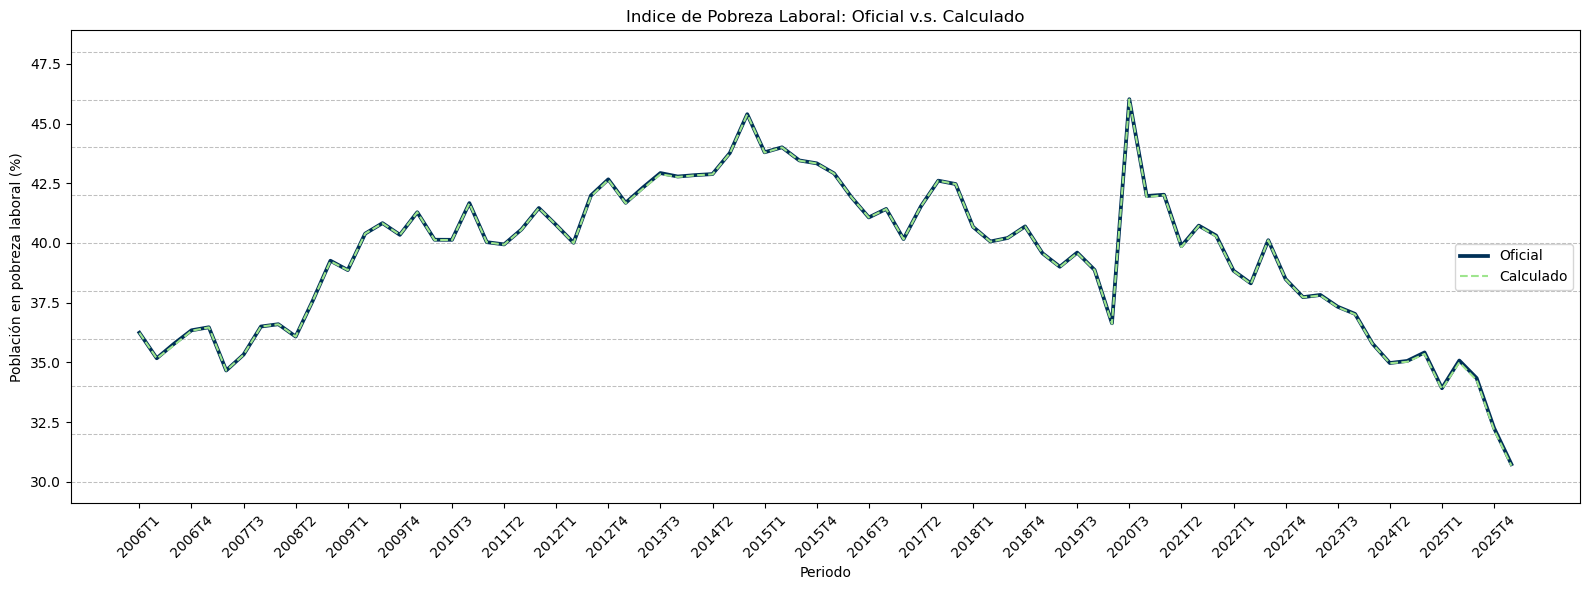

In [27]:
# Crear grafica de serie temporal del porcentaje de linea de pobreza
plt.figure(figsize=(16, 6))
sns.lineplot(data=pl_oficial, x="periodo", y="PL_oficial", label="Oficial",
            color="#003057", linewidth=2.7, linestyle="-")
sns.lineplot(data=pl_calculado, x="periodo", y="PL", label="Calculado",
            color="#9EE58D", linewidth=1.5, linestyle="--")
# Mostrar solo una etiqueta cada 4 trimestres
ticks = pl_oficial["periodo"].iloc[::3]
plt.xticks(ticks=ticks, rotation=45)
plt.title("Indice de Pobreza Laboral: Oficial v.s. Calculado")
plt.xlabel("Periodo")
plt.ylabel("Población en pobreza laboral (%)")

# Líneas horizontales cada 0.75
for y in np.arange(30, pl_oficial["PL_oficial"].max() + 3, 2):
    plt.axhline(y=y, color="gray", linewidth=0.75, 
                linestyle="--", alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

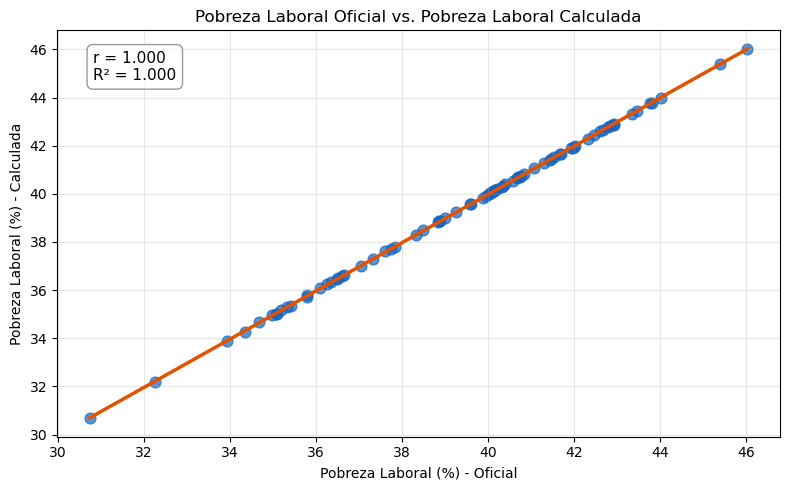

In [29]:
# Unir las dos series y eliminar valores faltantes
df_scatter = pd.DataFrame({
    "Oficial": pl_oficial["PL_oficial"],
    "Calculada": pl_calculado["PL"]
}).dropna()

# Determinar coeficiente de correlación de Pearson
r, p = stats.pearsonr(
    df_scatter["Oficial"],
    df_scatter["Calculada"]
)

# Coeficiente de determinación
r2 = r**2

# Scatterplot con regresión lineal
plt.figure(figsize=(8, 5))

sns.regplot(
    x=df_scatter["Oficial"],
    y=df_scatter["Calculada"],
    scatter_kws={
        "color": "#1565C0",
        "s": 60,
        "alpha": 0.7
    },
    line_kws={
        "color": "#E65100",
        "linewidth": 2.5
    }
)

# Mostrar r y R² en la gráfica
plt.text(
    0.05, 0.95,
    f"r = {r:.3f}\n"
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.8
    )
)

plt.title("Pobreza Laboral Oficial vs. Pobreza Laboral Calculada")
plt.xlabel("Pobreza Laboral (%) - Oficial")
plt.ylabel("Pobreza Laboral (%) - Calculada")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis y validación estadística del proceso replicado

Una vez comparada visualmente la serie oficial de pobreza laboral con la serie obtenida mediante el proceso replicado, se realiza una evaluación estadística de las diferencias observadas entre ambas estimaciones.

Para cada trimestre se define la diferencia:

$$
d_i = PL_{\text{Calculada},i} - PL_{\text{Oficial},i}
$$

Debido a que cada observación calculada corresponde exactamente al mismo trimestre que una observación oficial, los datos se encuentran emparejados. Por esta razón, puede analizarse el vector de diferencias mediante una **prueba t de una muestra (one-sample t-test)**, que en este contexto es equivalente a aplicar una prueba t pareada sobre ambas series.

La prueba evalúa si la diferencia media entre los resultados calculados y oficiales es estadísticamente distinta de cero.

Las hipótesis se plantean como:

$$
H_0:\mu_d = 0
$$

$$
H_1:\mu_d \neq 0
$$

donde $\mu_d$ representa la diferencia media poblacional entre ambas series.

Se utiliza un nivel de significancia de:

$$
\alpha = 0.05
$$

El resultado de la prueba produce un valor-p de aproximadamente:

$$
p = 5.3435\times10^{-11}
$$

Como $p < 0.05$, se rechaza la hipótesis nula. Por tanto, existe evidencia estadística de que la diferencia media entre la serie calculada y la serie oficial no es exactamente igual a cero.

Sin embargo, este resultado **no implica por sí mismo que ambas series sean sustancialmente diferentes**. Una prueba t puede detectar diferencias muy pequeñas cuando estas se presentan de manera consistente a lo largo de un número suficiente de observaciones.

En este caso, el resultado debe interpretarse conjuntamente con otros indicadores de concordancia. La correlación de Pearson y el coeficiente de determinación obtenidos entre ambas series son prácticamente:

$$
r \approx 1
$$

$$
R^2 \approx 1
$$

lo cual indica que las series reproducen prácticamente el mismo comportamiento temporal. La combinación de una correlación casi perfecta con el rechazo de $H_0$ sugiere que la discrepancia podría corresponder a un **sesgo sistemático de pequeña magnitud**, más que a diferencias aleatorias importantes entre ambas series.

Por esta razón, el t-test se utiliza como una prueba de detección de **sesgo medio**, y no como una prueba de igualdad o equivalencia entre los resultados.
rueba de igualdad o equivalencia entre los resultados.

In [37]:
# One-sample t-test sobre las diferencias

df_datos = df_scatter.copy()

# Diferencia:
# valor negativo -> la estimación calculada es menor que la oficial
# valor positivo -> la estimación calculada es mayor que la oficial
df_datos["dif"] = (
    df_datos["Calculada"]
    - df_datos["Oficial"]
)

media_hipotesis = 0
alpha = 0.05

test = stats.ttest_1samp(
    df_datos["dif"],
    popmean=media_hipotesis
)

print(f"Estadístico t: {test.statistic:.4f}")
print(f"Valor-p: {test.pvalue:.4e}")

if test.pvalue < alpha:
    print(
        "\nSe rechaza H0: existe evidencia estadística de que "
        "la diferencia media entre los valores calculados y "
        "oficiales es distinta de cero."
    )
else:
    print(
        "\nNo se rechaza H0: no existe evidencia estadística "
        "suficiente para afirmar que la diferencia media sea "
        "distinta de cero."
    )

Estadístico t: -7.5948
Valor-p: 5.3435e-11

Se rechaza H0: existe evidencia estadística de que la diferencia media entre los valores calculados y oficiales es distinta de cero.


### Magnitud de las diferencias entre la serie oficial y la serie calculada

El rechazo de la hipótesis nula en la prueba t indica la existencia de una diferencia media estadísticamente distinta de cero, pero no proporciona información suficiente sobre la **magnitud práctica de dicha discrepancia**.

Por esta razón, se analizan directamente las diferencias:

$$
d_i = PL_{\text{Calculada},i} - PL_{\text{Oficial},i}
$$

mediante estadísticos descriptivos y métricas de error.

Se consideran principalmente:

* **Media de las diferencias:** permite identificar la dirección y magnitud promedio del sesgo.
* **Mediana:** representa la diferencia central y es menos sensible a valores extremos.
* **Desviación estándar:** mide la variabilidad de las discrepancias entre trimestres.
* **Mínimo y máximo:** permiten identificar los extremos observados.
* **Cuartiles:** permiten estudiar la distribución de las diferencias.
* **MAE (Mean Absolute Error):** mide la magnitud promedio de las discrepancias sin considerar su signo.
* **Diferencia máxima absoluta:** identifica el trimestre con la mayor discrepancia entre ambas estimaciones.
* **RMSE (Root Mean Squared Error):** penaliza con mayor intensidad las discrepancias relativamente grandes.

Para los 80 trimestres analizados se obtiene una diferencia media aproximada de:

$$
\bar{d}=-0.01657\text{ puntos porcentuales}
$$

y un MAE de aproximadamente:

$$
MAE=0.01657\text{ puntos porcentuales}
$$

La mayor discrepancia absoluta observada es aproximadamente:

$$
\max(|d_i|)=0.08690\text{ puntos porcentuales}
$$

Asimismo, todas las diferencias observadas son negativas, con valores comprendidos aproximadamente entre:

$$
-0.08690 \leq d_i \leq -0.00097
$$

Esto significa que, en los 80 trimestres considerados, el proceso replicado produce sistemáticamente una estimación ligeramente inferior al valor oficial.

El hecho de que todas las diferencias presenten el mismo signo explica también por qué el MAE coincide prácticamente con el valor absoluto de la diferencia media:

$$
MAE \approx |\bar{d}|
$$

Los resultados indican, por tanto, una discrepancia de **muy pequeña magnitud pero consistentemente orientada en la misma dirección**.

A partir de este comportamiento se plantea como hipótesis de análisis que el proceso replicado podría presentar un **sesgo sistemático negativo**, potencialmente estable en el tiempo.

El siguiente paso consiste en estudiar gráficamente las diferencias por trimestre para determinar si este sesgo:

1. permanece aproximadamente constante a lo largo de toda la serie;
2. cambia gradualmente con el tiempo;
3. se concentra en determinados periodos;
4. o depende del nivel observado de pobreza laboral.

Una vez caracterizado el comportamiento del sesgo, podrá evaluarse la **equivalencia práctica y estadística** entre ambas series mediante una prueba de equivalencia TOST, utilizando un margen de equivalencia previamente justificado.
OST, utilizando un margen de equivalencia previamente justificado.

In [41]:
# Análisis descriptivo de las discrepancias

df_datos["dif"] = (
    df_datos["Calculada"]
    - df_datos["Oficial"]
)

df_datos["dif_abs"] = df_datos["dif"].abs()

# Estadísticos descriptivos
display(df_datos["dif"].describe())

media_diferencia = df_datos["dif"].mean()
mediana_diferencia = df_datos["dif"].median()

mae = df_datos["dif_abs"].mean()

rmse = (df_datos["dif"] ** 2).mean()**0.5


diferencia_max_abs = df_datos["dif_abs"].max()


print(f"Diferencia media:          {media_diferencia:.6f} pp")
print(f"Mediana de la diferencia:  {mediana_diferencia:.6f} pp")
print(f"MAE:                       {mae:.6f} pp")
print(f"RMSE:                      {rmse:.6f} pp")
print(f"Diferencia máxima absoluta:{diferencia_max_abs:.6f} pp")


# Periodos con las mayores discrepancias
display(df_datos.sort_values("dif_abs", ascending=False).head(10))


count    80.000000
mean     -0.016571
std       0.019515
min      -0.086897
25%      -0.019904
50%      -0.009142
75%      -0.004393
max      -0.000965
Name: dif, dtype: float64

Diferencia media:          -0.016571 pp
Mediana de la diferencia:  -0.009142 pp
MAE:                       0.016571 pp
RMSE:                      0.025508 pp
Diferencia máxima absoluta:0.086897 pp


,Oficial,Calculada,dif,dif_abs
77,34.339595,34.252698,-0.086897,0.086897
76,35.077605,34.999696,-0.077909,0.077909
78,32.255436,32.177581,-0.077855,0.077855
2,35.783874,35.721112,-0.062762,0.062762
74,35.416246,35.353699,-0.062547,0.062547
79,30.737136,30.676722,-0.060414,0.060414
30,42.926172,42.874866,-0.051306,0.051306
29,42.322709,42.273999,-0.048710,0.048710
58,41.965963,41.921934,-0.044029,0.044029
75,33.918090,33.878563,-0.039527,0.039527


### Análisis gráfico del sesgo y concordancia entre las estimaciones

Los resultados anteriores muestran que la diferencia entre la pobreza laboral calculada y la oficial es pequeña en magnitud, pero presenta una dirección sistemática: para los 80 trimestres analizados, la estimación calculada se encuentra por debajo de la oficial.

Para estudiar el comportamiento de esta discrepancia se define:

$$
d_t = PL_{\text{Calculada},t} - PL_{\text{Oficial},t}
$$

donde los valores negativos indican una subestimación respecto al resultado oficial y los valores positivos, una sobreestimación.

Se utilizan dos representaciones gráficas complementarias.

#### Evolución temporal de las diferencias

La primera gráfica representa $d_t$ para cada trimestre. Su objetivo es determinar si el sesgo observado permanece aproximadamente estable a través del tiempo o si existen periodos en los que cambia su magnitud.

Se incorporan como referencias:

* $d_t = 0$, que representa coincidencia exacta entre ambas estimaciones.
* La diferencia media observada, aproximadamente:

$$
\bar{d} = -0.0166\ \text{pp}
$$

La serie muestra que las diferencias permanecen por debajo de cero durante todo el periodo analizado, confirmando visualmente la dirección negativa del sesgo. Durante gran parte de la serie, las discrepancias son pequeñas y relativamente cercanas a cero, aunque existen episodios aislados con diferencias de mayor magnitud.

Sin embargo, hacia la parte final de la serie, particularmente a partir de aproximadamente **2024T2**, se observa un incremento más persistente en la magnitud de las diferencias negativas. Los mayores errores de la serie se concentran en estos periodos recientes.

Este comportamiento sugiere que el sesgo podría no ser completamente constante en el tiempo y plantea la hipótesis exploratoria de un posible cambio en su comportamiento durante los últimos trimestres. La identificación visual de 2024T2 debe considerarse inicialmente como un hallazgo exploratorio y no como evidencia suficiente de una ruptura estructural.

#### Gráfico de Bland–Altman

Como análisis complementario se utiliza un **gráfico de Bland–Altman**, diseñado para evaluar la concordancia entre dos métodos o procedimientos que estiman una misma magnitud.

Para cada trimestre se representa:

$$
x_t =
\frac{
PL_{\text{Oficial},t} + PL_{\text{Calculada},t}
}{2}
$$

frente a:

$$
y_t =
PL_{\text{Calculada},t} - PL_{\text{Oficial},t}
$$

De esta manera, el eje horizontal representa el nivel promedio de pobreza laboral estimado por ambos procedimientos y el eje vertical representa la discrepancia entre ellos.

El gráfico incorpora tres referencias principales:

* la línea de diferencia cero, correspondiente a concordancia exacta;
* el sesgo medio $\bar{d}$;
* los límites de concordancia descriptivos:

$$
\bar{d} \pm 1.96s_d
$$

donde $s_d$ es la desviación estándar de las diferencias.

El gráfico confirma que la mayor parte de las observaciones presenta discrepancias pequeñas y próximas a cero, aunque desplazadas sistemáticamente hacia valores negativos. También se observan algunos trimestres con diferencias considerablemente mayores, varios de los cuales se encuentran por debajo del límite inferior de concordancia.

Además, las discrepancias de mayor magnitud aparecen principalmente en observaciones con niveles relativamente bajos de pobreza laboral. No obstante, estos niveles también corresponden en buena medida a los periodos más recientes de la serie, por lo que todavía no puede determinarse si el incremento de las diferencias está relacionado con el **nivel del indicador**, con un **cambio temporal en el proceso de estimación**, o con ambos factores.

#### Interpretación preliminar

El análisis conjunto de ambas gráficas refuerza los resultados obtenidos previamente:

1. Existe un **sesgo negativo sistemático**, ya que la estimación replicada se mantiene por debajo de la oficial.
2. La magnitud promedio del sesgo es pequeña, aproximadamente $-0.0166$ puntos porcentuales.
3. Durante buena parte de la serie, las discrepancias permanecen relativamente próximas a cero, aunque existen desviaciones puntuales.
4. En los periodos más recientes se observa un incremento más persistente en la magnitud del error, especialmente a partir de aproximadamente **2024T2**.
5. La presencia de observaciones fuera de los límites de concordancia indica que el comportamiento de las diferencias no puede caracterizarse únicamente mediante su promedio.

Por tanto, antes de evaluar formalmente la **equivalencia estadística** entre la serie oficial y la calculada mediante una prueba TOST, es necesario investigar si el aparente incremento reciente del sesgo constituye un cambio temporal sistemático y determinar qué componentes del proceso de cálculo podrían explicarlo.mporal sistemático y determinar qué componentes del proceso de cálculo podrían explicarlo.
l sistemático y determinar qué componentes del proceso de cálculo podrían explicarlo.

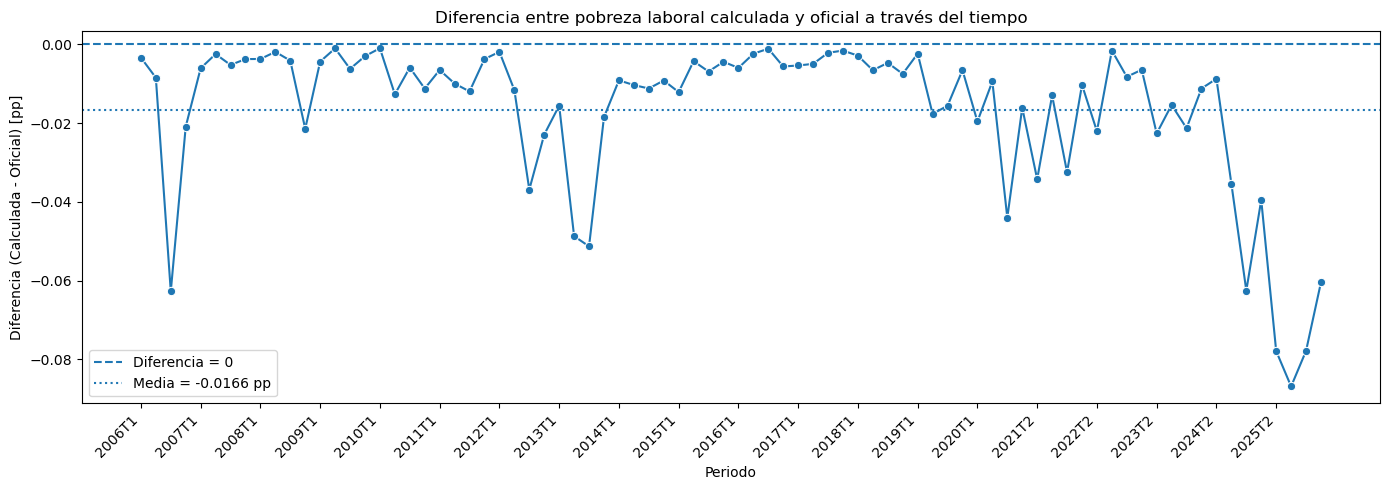

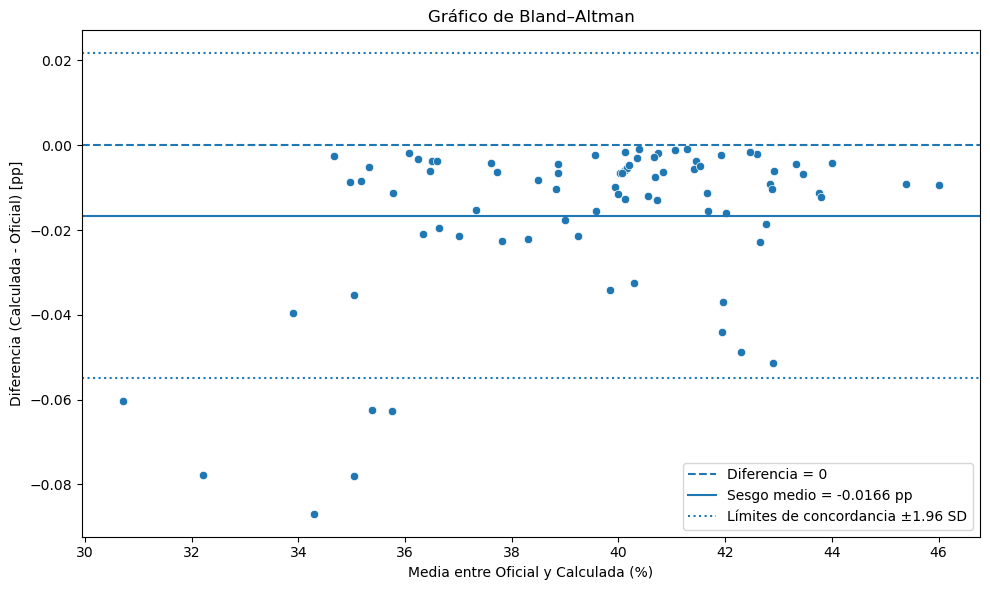

In [63]:
# Re ordenar por periodo y agregar el periodo
df_datos.sort_index()
df_datos["Periodo"]= pl_oficial["periodo"]


# 1 Grafica de sesgo
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_datos, x="Periodo", y="dif", marker="o")
plt.axhline(y=0, linestyle="--", label="Diferencia = 0") # Línea de media cero

# 1.A) Línea del sesgo medio observado
plt.axhline(
    y=df_datos["dif"].mean(),
    linestyle=":",
    label=f"Media = {df_datos['dif'].mean():.4f} pp"
)

# 1.B) Mostrar una etiqueta por año
ticks = range(0, len(df_datos), 4)
plt.xticks(ticks=ticks, labels=df_datos["Periodo"].iloc[ticks], rotation=45, ha="right")

plt.xlabel("Periodo")
plt.ylabel("Diferencia (Calculada - Oficial) [pp]")
plt.title(
    "Diferencia entre pobreza laboral calculada y oficial a través del tiempo"
)

plt.legend()
plt.tight_layout()
plt.show()

# 2 Crear grafica de Bland-Altman
# 2.A) Calcular la media de los dos valores (oficales y calculados)
df_datos["media_metodos"] = (
    df_datos["Oficial"]
    + df_datos["Calculada"]
) / 2

# 2.B) Calculo de media y desv. est. de diferencia de calculado y oficial
sesgo = df_datos["dif"].mean()
sd_dif = df_datos["dif"].std()

# 2.C) Limites de concordancia
limite_superior = sesgo + 1.96 * sd_dif
limite_inferior = sesgo - 1.96 * sd_dif

# 2.D) Grafica de Bland-Almant
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_datos, x="media_metodos", y="dif")

plt.axhline(y=0, linestyle="--", label="Diferencia = 0")
plt.axhline(y=sesgo, linestyle="-", label=f"Sesgo medio = {sesgo:.4f} pp")
plt.axhline(y=limite_superior, linestyle=":", 
            label="Límites de concordancia ±1.96 SD")
plt.axhline(y=limite_inferior, linestyle=":")

plt.xlabel("Media entre Oficial y Calculada (%)")
plt.ylabel("Diferencia (Calculada - Oficial) [pp]")
plt.title("Gráfico de Bland–Altman")

plt.legend()
plt.tight_layout()
plt.show()

### Comparación exploratoria del sesgo por periodo y nivel de pobreza laboral

Las gráficas anteriores muestran que la diferencia entre la estimación calculada y la oficial no presenta un comportamiento completamente homogéneo a lo largo de la serie. Aunque durante la mayor parte del periodo analizado las discrepancias permanecen relativamente próximas a cero, a partir de aproximadamente **2024T2** se observa un incremento más persistente en la magnitud del sesgo negativo.

Para estudiar este comportamiento se realizan cuatro análisis exploratorios complementarios. Primero se divide la serie en dos grupos temporales:

- **Hasta 2024T1**
- **Desde 2024T2**

Para cada grupo se calculan el número de observaciones, media, mediana, desviación estándar, mínimo y máximo de las diferencias, además de las métricas **MAE**, **RMSE** y diferencia máxima absoluta.

Posteriormente se evalúa la hipótesis sugerida por el gráfico de Bland–Altman de que las discrepancias podrían aumentar cuando el nivel de pobreza laboral es bajo. Para ello se divide la serie según el nivel promedio obtenido entre ambas estimaciones:

$$
PL_{\text{media},t}
=
\frac{
PL_{\text{Oficial},t}
+
PL_{\text{Calculada},t}
}{2}
$$

utilizando inicialmente como punto exploratorio el nivel de **34 %**.

Finalmente, se cruza la clasificación temporal con la clasificación por nivel de pobreza laboral y se identifican los periodos con las mayores diferencias absolutas.

#### Resultados por periodo temporal

La comparación muestra una diferencia clara entre ambos segmentos de la serie.

Para los **72 trimestres hasta 2024T1**, la diferencia media es aproximadamente:

$$
\bar{d}_{\leq 2024T1}
=
-0.0122\ \text{pp}
$$

mientras que para los **8 trimestres desde 2024T2** aumenta en magnitud hasta aproximadamente:

$$
\bar{d}_{\geq 2024T2}
=
-0.0562\ \text{pp}
$$

Esto implica que, en términos absolutos, la discrepancia media desde 2024T2 es aproximadamente **4.6 veces mayor** que la observada durante el resto de la serie.

El mismo comportamiento aparece en las demás métricas de error:

| Grupo temporal | MAE | RMSE | Diferencia máxima absoluta |
|---|---:|---:|---:|
| Hasta 2024T1 | 0.0122 pp | 0.0174 pp | 0.0628 pp |
| Desde 2024T2 | 0.0562 pp | 0.0614 pp | 0.0869 pp |

Además, la mediana de las diferencias pasa de aproximadamente:

$$
-0.0079\ \text{pp}
$$

a:

$$
-0.0615\ \text{pp}
$$

por lo que el incremento observado no parece depender únicamente de uno o dos valores extremos. El centro mismo de la distribución de las diferencias se desplaza hacia valores más negativos en los periodos recientes.

Estos resultados aportan evidencia descriptiva de un posible **cambio en el comportamiento del sesgo a partir de 2024T2**. No obstante, este punto de corte fue identificado mediante inspección gráfica y debe considerarse inicialmente como una hipótesis exploratoria, no como una ruptura estructural demostrada estadísticamente.

#### Resultados según el nivel de pobreza laboral

Al dividir las observaciones según el nivel promedio de pobreza laboral se obtiene también una diferencia importante.

Para los periodos con:

$$
PL_{\text{media}} < 34\%
$$

la diferencia media es aproximadamente:

$$
-0.0593\ \text{pp}
$$

mientras que para:

$$
PL_{\text{media}} \geq 34\%
$$

es aproximadamente:

$$
-0.0149\ \text{pp}
$$

A primera vista, este resultado podría sugerir que el método replicado pierde precisión cuando el nivel de pobreza laboral disminuye.

Sin embargo, la tabla cruzada entre ambas clasificaciones muestra una limitación importante: **los tres únicos periodos con pobreza laboral inferior a 34 % pertenecen al grupo posterior a 2024T2**.

Por tanto, los efectos de **tiempo** y **nivel de pobreza laboral** están parcialmente confundidos. Con la evidencia actual no es posible determinar si el incremento de las discrepancias se debe principalmente a que la pobreza laboral alcanza valores bajos, a algún cambio ocurrido en los periodos recientes, o a una combinación de ambos factores.

Esta interpretación se refuerza al revisar los periodos con las mayores diferencias absolutas, ya que varias de las discrepancias más grandes posteriores a 2024T2 ocurren con niveles de pobreza laboral superiores a 34 %. Por ello, el nivel de 34 % no debe interpretarse todavía como un umbral a partir del cual el procedimiento replicado comienza a fallar.

#### Hallazgo principal

El resultado más relevante de este análisis es que la magnitud del sesgo aumenta considerablemente en los periodos posteriores a **2024T2**:

$$
\left|
\bar{d}_{\geq 2024T2}
\right|
\gg
\left|
\bar{d}_{\leq 2024T1}
\right|
$$

La discrepancia continúa siendo pequeña en términos absolutos —menor a una décima de punto porcentual incluso en el peor caso observado—, pero presenta un cambio suficientemente marcado como para justificar una investigación específica de los periodos recientes.

El siguiente paso consiste en determinar si este comportamiento puede explicarse por:

1. un efecto temporal asociado a los periodos posteriores a 2024T2;
2. el nivel observado de pobreza laboral;
3. una combinación de ambos factores;
4. o cambios en alguna de las variables y reglas utilizadas dentro del proceso replicado, como imputación de ingresos, exclusión de hogares, factores de expansión o población elegible.

Para separar inicialmente los efectos temporal y de nivel de pobreza laboral se analizará la diferencia mediante un modelo que incorpore simultáneamente ambas variables antes de investigar posibles cambios metodológicos en el proceso de cálculo.

In [99]:
# Comparación exploratoria antes/después de 2024T2
# _________________________________________________________

df_sesgo = df_datos.copy()
df_sesgo["Año"] = df_sesgo["Periodo"].str[:4].astype(int)
df_sesgo["Trimestre"] = df_sesgo["Periodo"].str[5:].astype(int)

df_sesgo["post_2024T2"] = (
    (df_sesgo["Año"] > 2024)
    | (
        (df_sesgo["Año"] == 2024)
        & (df_sesgo["Trimestre"] >= 2)
    )
)

df_sesgo["grupo_temporal"] = df_sesgo["post_2024T2"].map({
    False: "Hasta 2024T1",
    True: "Desde 2024T2"
})

resumen_temporal = (
    df_sesgo
    .groupby("grupo_temporal")["dif"]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max"
    )
)

display(resumen_temporal)

resumen_error_temporal = (
    df_sesgo
    .groupby("grupo_temporal")
    .apply(
        lambda x: pd.Series({
            "MAE": x["dif"].abs().mean(),
            "RMSE": (x["dif"].pow(2).mean()) ** 0.5,
            "Max_abs": x["dif"].abs().max(),
        }),
        include_groups=False
    )
)

display(resumen_error_temporal)

,n,media,mediana,desviacion,minimo,maximo
grupo_temporal,,,,,,
Desde 2024T2,8,-0.056155,-0.061481,0.026476,-0.086897,-0.008720
Hasta 2024T1,72,-0.012173,-0.007855,0.012589,-0.062762,-0.000965


,MAE,RMSE,Max_abs
grupo_temporal,,,
Desde 2024T2,0.056155,0.061374,0.086897
Hasta 2024T1,0.012173,0.017448,0.062762


In [93]:
df_sesgo["PL_media"] = (
    df_sesgo["Oficial"]
    + df_sesgo["Calculada"]
) / 2
df_sesgo["grupo_nivel"] = pd.cut(
    df_sesgo["PL_media"],
    bins=[-float("inf"), 34, float("inf")],
    labels=["PL < 34%", "PL ≥ 34%"],
    right=False
)
resumen_nivel = (
    df_sesgo
    .groupby("grupo_nivel", observed=True)["dif"]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max"
    )
)

display(resumen_nivel)
resumen_error_nivel = (
    df_sesgo
    .groupby("grupo_nivel", observed=True)
    .apply(
        lambda x: pd.Series({
            "MAE": x["dif"].abs().mean(),
            "RMSE": (x["dif"].pow(2).mean()) ** 0.5,
            "Max_abs": x["dif"].abs().max(),
        }),
        include_groups=False
    )
)

display(resumen_error_nivel)

,n,media,mediana,desviacion,minimo,maximo
grupo_nivel,,,,,,
PL < 34%,3,-0.059266,-0.060414,0.019190,-0.077855,-0.039527
PL ≥ 34%,77,-0.014907,-0.008720,0.017647,-0.086897,-0.000965


,MAE,RMSE,Max_abs
grupo_nivel,,,
PL < 34%,0.059266,0.061302,0.077855
PL ≥ 34%,0.014907,0.023013,0.086897


In [95]:
tabla_cruce = pd.crosstab(
    df_sesgo["grupo_temporal"],
    df_sesgo["grupo_nivel"]
)

display(tabla_cruce)

grupo_nivel,PL < 34%,PL ≥ 34%
grupo_temporal,,
Desde 2024T2,3,5
Hasta 2024T1,0,72


In [97]:
display(
    df_sesgo[
        [
            "Año",
            "Trimestre",
            "Oficial",
            "Calculada",
            "PL_media",
            "dif",
            "dif_abs",
            "grupo_temporal",
            "grupo_nivel",
        ]
    ]
    .sort_values(
        "dif_abs",
        ascending=False
    )
    .head(20)
)

,Año,Trimestre,Oficial,Calculada,PL_media,dif,dif_abs,grupo_temporal,grupo_nivel
77,2025,3,34.339595,34.252698,34.296147,-0.086897,0.086897,Desde 2024T2,PL ≥ 34%
76,2025,2,35.077605,34.999696,35.038650,-0.077909,0.077909,Desde 2024T2,PL ≥ 34%
78,2025,4,32.255436,32.177581,32.216509,-0.077855,0.077855,Desde 2024T2,PL < 34%
2,2006,3,35.783874,35.721112,35.752493,-0.062762,0.062762,Hasta 2024T1,PL ≥ 34%
74,2024,4,35.416246,35.353699,35.384973,-0.062547,0.062547,Desde 2024T2,PL ≥ 34%
79,2026,1,30.737136,30.676722,30.706929,-0.060414,0.060414,Desde 2024T2,PL < 34%
30,2013,3,42.926172,42.874866,42.900519,-0.051306,0.051306,Hasta 2024T1,PL ≥ 34%
29,2013,2,42.322709,42.273999,42.298354,-0.048710,0.048710,Hasta 2024T1,PL ≥ 34%
58,2020,4,41.965963,41.921934,41.943949,-0.044029,0.044029,Hasta 2024T1,PL ≥ 34%
75,2025,1,33.918090,33.878563,33.898327,-0.039527,0.039527,Desde 2024T2,PL < 34%


### Análisis de heterocedasticidad y autocorrelación

Con el objetivo de distinguir si el incremento observado en las discrepancias está asociado principalmente con los **periodos recientes** o con el **nivel de pobreza laboral**, se estima un modelo de regresión lineal sobre las diferencias entre ambos procedimientos:

$$
d_t =
PL_{\text{Calculada},t}
-
PL_{\text{Oficial},t}
$$

El modelo utilizado es:

$$
d_t =
\beta_0
+
\beta_1 Post2024T2_t
+
\beta_2 PL_{\text{media},t}
+
\varepsilon_t
$$

donde:

- $Post2024T2_t$ es una variable dicotómica que toma el valor 0 hasta 2024T1 y 1 desde 2024T2.
- $PL_{\text{media},t}$ corresponde al promedio entre la estimación oficial y la calculada para cada trimestre.
- $\beta_1$ permite identificar si existe una discrepancia adicional asociada con los periodos recientes, manteniendo constante el nivel de pobreza laboral.
- $\beta_2$ permite evaluar si el nivel de pobreza laboral explica independientemente la magnitud de la discrepancia.

#### Resultados del modelo OLS

La regresión OLS muestra que la variable `post_2024T2` presenta un coeficiente aproximado de:

$$
\hat{\beta}_1 = -0.0432
$$

con un valor-p inferior a 0.001.

Esto indica que, controlando por el nivel de pobreza laboral, los periodos desde 2024T2 presentan una diferencia `Calculada - Oficial` aproximadamente **0.043 puntos porcentuales más negativa** que los periodos anteriores.

En contraste, el coeficiente asociado a $PL_{\text{media}}$ es prácticamente igual a cero y no resulta estadísticamente significativo:

$$
p \approx 0.85
$$

Por tanto, dentro de este modelo no se encuentra evidencia de que el nivel de pobreza laboral explique por sí mismo el incremento de las discrepancias una vez controlado el efecto temporal.

El modelo presenta un coeficiente de determinación aproximado de:

$$
R^2 = 0.463
$$

lo que indica que las variables incluidas explican alrededor del 46 % de la variabilidad observada en las diferencias.

#### Corrección HAC / Newey-West

Dado que las observaciones corresponden a una **serie temporal trimestral**, los errores del modelo pueden presentar heterocedasticidad o autocorrelación. En particular, un estadístico Durbin-Watson cercano a 1.28 sugiere la posible presencia de autocorrelación positiva en los residuos.

Para evitar que esta dependencia temporal produzca errores estándar demasiado optimistas, se utiliza una estimación de la matriz de covarianzas **HAC (Heteroskedasticity and Autocorrelation Consistent)** mediante el método de **Newey-West**, considerando hasta cuatro rezagos trimestrales.

Esta corrección no modifica los coeficientes estimados por OLS, sino que ajusta:

- los errores estándar;
- los estadísticos de contraste;
- los valores-p;
- y los intervalos de confianza;

para hacer la inferencia más robusta ante heterocedasticidad y autocorrelación temporal.

Después de aplicar la corrección HAC/Newey-West, el efecto asociado a los periodos desde 2024T2 se mantiene:

$$
\hat{\beta}_1 = -0.04324
$$

con:

$$
p = 0.000434
$$

y un intervalo de confianza del 95 % aproximadamente igual a:

$$
[-0.0673,\,-0.0192]
$$

El intervalo se mantiene completamente por debajo de cero, por lo que el resultado continúa siendo estadísticamente significativo aun después de utilizar una estimación robusta de los errores estándar.

Por el contrario, el nivel medio de pobreza laboral sigue sin mostrar un efecto independiente significativo:

$$
\hat{\beta}_2 \approx 0.00012
$$

$$
p \approx 0.870
$$

#### Interpretación

Los resultados de la regresión OLS y de la corrección HAC/Newey-West proporcionan mayor sustento a la hipótesis de que el incremento observado en las discrepancias está asociado principalmente con los **periodos más recientes de la serie**, y no con el nivel de pobreza laboral por sí mismo.

En particular, la evidencia disponible indica que los periodos agrupados desde 2024T2 presentan un sesgo negativo adicional respecto al resto de la serie, incluso después de controlar por el nivel del indicador y corregir la inferencia por heterocedasticidad y autocorrelación.

Este resultado debe interpretarse como una **asociación temporal observada dentro de la muestra analizada**. No implica que el error necesariamente continuará aumentando en periodos futuros ni permite afirmar, por sí solo, que exista una tendencia creciente permanente.

Asimismo, debido a que 2024T2 fue identificado inicialmente mediante inspección gráfica, este punto de corte debe considerarse exploratorio. Los resultados muestran que la separación temporal es estadísticamente informativa, pero no constituyen por sí mismos una demostración formal de que 2024T2 sea el punto exacto de una ruptura estructural.

En conjunto, la evidencia obtenida hasta este punto sugiere que la reproducción del indicador mantiene una concordancia muy elevada con los resultados oficiales, pero presenta un **sesgo negativo pequeño cuya magnitud aumenta de manera apreciable en los periodos recientes analizados**.

In [106]:
import statsmodels.api as sm

# Preparación de variables para regresión
# ___________________________________________

# Crear PL_media otra vez
df_sesgo["PL_media"] = (
    df_sesgo["Oficial"]
    + df_sesgo["Calculada"]
) / 2

# Variables explicativas
X = df_sesgo[["post_2024T2", "PL_media"]].copy()

# Convertir variable booleana a 0/1
X["post_2024T2"] = (X["post_2024T2"].astype(int))

# Agregar intercepto β0
X = sm.add_constant(X)

# Variable dependiente
y = df_sesgo["dif"]

display(X.head())
display(y.head())

# Regresión OLS
modelo_ols = sm.OLS(y, X).fit()
print(modelo_ols.summary())

,const,post_2024T2,PL_media
0,1.0,0,36.241493
1,1.0,0,35.169358
2,1.0,0,35.752493
3,1.0,0,36.333251
4,1.0,0,36.467783


0   -0.003336
1   -0.008450
2   -0.062762
3   -0.020900
4   -0.006053
Name: dif, dtype: float64

                            OLS Regression Results                            
Dep. Variable:                    dif   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     33.22
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           3.97e-11
Time:                        10:23:52   Log-Likelihood:                 226.80
No. Observations:                  80   AIC:                            -447.6
Df Residuals:                      77   BIC:                            -440.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0170      0.026     -0.649      

In [112]:
# Regresión OLS con errores estándar HAC / Newey-West
# ____________________________________________________________

modelo_hac = sm.OLS(
    y,
    X
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 4
    }
)

print(modelo_hac.summary())

# Resumen - Extracto
resultados_hac = pd.DataFrame({
    "coeficiente": modelo_hac.params,
    "error_estandar_HAC": modelo_hac.bse,
    "estadistico": modelo_hac.tvalues,
    "valor_p": modelo_hac.pvalues,
    "IC_95_inf": modelo_hac.conf_int()[0],
    "IC_95_sup": modelo_hac.conf_int()[1],
})

display(resultados_hac)

                            OLS Regression Results                            
Dep. Variable:                    dif   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     7.815
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           0.000812
Time:                        11:07:02   Log-Likelihood:                 226.80
No. Observations:                  80   AIC:                            -447.6
Df Residuals:                      77   BIC:                            -440.4
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0170      0.029     -0.588      

,coeficiente,error_estandar_HAC,estadistico,valor_p,IC_95_inf,IC_95_sup
const,-0.017002,0.028924,-0.587803,0.556664,-0.073692,0.039688
post_2024T2,-0.043240,0.012290,-3.518321,0.000434,-0.067328,-0.019152
PL_media,0.000120,0.000736,0.163669,0.869992,-0.001322,0.001562


### Prueba de equivalencia estadística (TOST)

Una diferencia estadísticamente significativa entre dos estimaciones no implica necesariamente que dicha diferencia sea relevante en términos prácticos. Por esta razón, después de estudiar la existencia, magnitud y comportamiento temporal de las discrepancias entre la pobreza laboral oficial y la calculada, se utiliza una prueba de equivalencia **TOST (Two One-Sided Tests)**.

A diferencia de una prueba *t* convencional, donde la hipótesis nula plantea que la diferencia media es igual a cero, TOST parte de una hipótesis nula de **no equivalencia**.

Sea:

$$
d_t =
PL_{\text{Calculada},t}
-
PL_{\text{Oficial},t}
$$

y sea $\Delta$ el máximo error medio considerado prácticamente tolerable. Las hipótesis se plantean como:

$$
H_0:
\mu_d \leq -\Delta
\quad\text{o}\quad
\mu_d \geq +\Delta
$$

frente a:

$$
H_1:
-\Delta < \mu_d < +\Delta
$$

Por tanto, si ambas pruebas unilaterales permiten rechazar $H_0$, se obtiene evidencia estadística suficiente para establecer que la diferencia media se encuentra dentro del intervalo de equivalencia previamente definido.

#### Definición del margen de equivalencia

La documentación oficial consultada de pobreza laboral no establece un margen institucional específico para evaluar la equivalencia entre una reproducción independiente y los resultados oficiales. Por esta razón, para este ejercicio se establece un **margen práctico de equivalencia** de:

$$
\boxed{\Delta = 0.05\ \text{puntos porcentuales}}
$$

por lo que el intervalo de equivalencia utilizado es:

$$
[-0.05,\,+0.05]\ \text{pp}
$$

Este criterio se fundamenta en la **resolución con la que se publican los resultados oficiales del indicador**. INEGI presenta el porcentaje de población en pobreza laboral con una cifra decimal; por ejemplo, los resultados nacionales son publicados en valores como 33.9 %, 32.3 % o 30.7 %. Por ello, 0.05 puntos porcentuales representa media unidad de la resolución utilizada para comunicar públicamente el indicador.

Debe enfatizarse que **±0.05 pp no constituye un margen oficial de equivalencia definido por INEGI o CONEVAL**. Es un criterio práctico adoptado específicamente para esta auditoría, tomando como referencia la resolución de publicación de los resultados oficiales.

[Boletín oficial de Pobreza Laboral, primer trimestre de 2026 — INEGI](https://www.inegi.org.mx/contenidos/saladeprensa/boletines/2026/pl/pl2026_05.pdf)

La prueba se realiza para tres conjuntos de observaciones:

1. la serie completa;
2. los periodos hasta 2024T1;
3. los periodos desde 2024T2.

Esta separación permite evaluar si la equivalencia observada para el conjunto de la serie se mantiene en los dos segmentos temporales identificados durante el análisis previo.

#### Resultados para la serie completa

Para los 80 trimestres analizados se obtiene una diferencia media de:

$$
\bar{d} = -0.01657\ \text{pp}
$$

y un valor-p TOST de aproximadamente:

$$
p = 1.13 \times 10^{-25}
$$

Dado que:

$$
p < 0.05
$$

se rechaza la hipótesis nula de no equivalencia. Por tanto, **existe evidencia estadística para considerar equivalentes la serie oficial y la serie calculada dentro del margen práctico de ±0.05 puntos porcentuales**.

Este resultado no significa que ambas series sean exactamente iguales. La diferencia sistemática identificada anteriormente continúa existiendo, pero su magnitud media resulta suficientemente pequeña para encontrarse dentro del criterio de equivalencia establecido.

#### Resultados hasta 2024T1

Para los 72 trimestres comprendidos hasta 2024T1, la diferencia media es:

$$
\bar{d} = -0.01217\ \text{pp}
$$

con:

$$
p_{\text{TOST}} \approx 9.04 \times 10^{-38}
$$

El intervalo de confianza del 90 % para la diferencia media es aproximadamente:

$$
[-0.01465,\,-0.00970]\ \text{pp}
$$

y se encuentra completamente contenido dentro del intervalo:

$$
[-0.05,\,+0.05]\ \text{pp}
$$

Por tanto, se obtiene **evidencia estadística clara de equivalencia entre los resultados oficiales y calculados hasta 2024T1** bajo el margen establecido.

#### Resultados desde 2024T2

Para los ocho trimestres comprendidos desde 2024T2, la diferencia media aumenta en magnitud hasta:

$$
\bar{d} = -0.05616\ \text{pp}
$$

y la prueba obtiene:

$$
p_{\text{TOST}} \approx 0.734
$$

Como:

$$
p > 0.05
$$

no es posible rechazar la hipótesis nula de no equivalencia. En consecuencia, **no existe evidencia estadística suficiente para establecer equivalencia entre ambas estimaciones desde 2024T2 bajo el margen práctico de ±0.05 puntos porcentuales**.

Este resultado debe interpretarse cuidadosamente: TOST no demuestra que ambas series sean necesariamente "no equivalentes" en cualquier sentido posible. Indica específicamente que, con los datos disponibles y bajo el margen previamente establecido de ±0.05 pp, **no puede establecerse equivalencia estadística para este segmento temporal**.

Además, este último análisis contiene únicamente ocho observaciones, por lo que sus resultados deben considerarse junto con la evidencia obtenida previamente mediante el análisis de las diferencias, Bland–Altman y la regresión con errores estándar HAC/Newey-West.videncia obtenida previamente mediante el análisis de las diferencias, Bland–Altman y la regresión con errores estándar HAC/Newey-West.

In [122]:
from statsmodels.stats.weightstats import ttost_paired
# Prueba TOST de equivalencia - Serie completa
# ____________________________________________________________

alpha = 0.05

# Margen práctico de equivalencia en puntos porcentuales
limite_inferior = -0.05
limite_superior = 0.05

# TOST pareado
p_tost, test_inferior, test_superior = ttost_paired(
    df_datos["Calculada"],
    df_datos["Oficial"],
    low=limite_inferior,
    upp=limite_superior
)

# Resultados de las dos pruebas unilaterales
t_inferior, p_inferior, gl_inferior = test_inferior
t_superior, p_superior, gl_superior = test_superior


print("=" * 60)
print("PRUEBA TOST DE EQUIVALENCIA")
print("=" * 60)

print(
    f"Margen de equivalencia: "
    f"[{limite_inferior:.2f}, {limite_superior:.2f}] pp"
)

print(f"Número de periodos: {len(df_datos)}")

print(
    f"Diferencia media "
    f"(Calculada - Oficial): "
    f"{df_datos['dif'].mean():.6f} pp"
)

print("\nPrueba unilateral inferior:")
print(f"  t = {t_inferior:.4f}")
print(f"  p = {p_inferior:.4e}")

print("\nPrueba unilateral superior:")
print(f"  t = {t_superior:.4f}")
print(f"  p = {p_superior:.4e}")

print(f"\nValor-p TOST: {p_tost:.4e}")

# Interpretación

if p_tost < alpha:
    print(
        "\nSe rechaza la hipótesis nula de no equivalencia."
    )
    print(
        "Existe evidencia estadística para considerar "
        "equivalentes la serie oficial y la serie calculada "
        "dentro del margen de ±0.05 puntos porcentuales."
    )
else:
    print(
        "\nNo se rechaza la hipótesis nula de no equivalencia."
    )
    print(
        "No existe evidencia estadística suficiente para "
        "afirmar equivalencia dentro del margen de "
        "±0.05 puntos porcentuales."
    )

PRUEBA TOST DE EQUIVALENCIA
Margen de equivalencia: [-0.05, 0.05] pp
Número de periodos: 80
Diferencia media (Calculada - Oficial): -0.016571 pp

Prueba unilateral inferior:
  t = 15.3215
  p = 1.1305e-25

Prueba unilateral superior:
  t = -30.5111
  p = 9.0113e-46

Valor-p TOST: 1.1305e-25

Se rechaza la hipótesis nula de no equivalencia.
Existe evidencia estadística para considerar equivalentes la serie oficial y la serie calculada dentro del margen de ±0.05 puntos porcentuales.


In [128]:
# TOST de equivalencia - Hasta 2024T1
# _____________________________________________________________

alpha = 0.05

limite_inferior = -0.05
limite_superior = 0.05

# Filtrar hasta 2024T1 inclusive
df_tost_pre = df_sesgo[
    (df_sesgo["Año"] < 2024)
    | (
        (df_sesgo["Año"] == 2024)
        & (df_sesgo["Trimestre"] <= 1)
    )
].copy()

# Asegurar diferencia consistente
df_tost_pre["dif"] = (
    df_tost_pre["Calculada"]
    - df_tost_pre["Oficial"]
)


# Prueba TOST pareada
p_tost_pre, test_inferior_pre, test_superior_pre = ttost_paired(
    df_tost_pre["Calculada"],
    df_tost_pre["Oficial"],
    low=limite_inferior,
    upp=limite_superior
)

t_inf_pre, p_inf_pre, gl_inf_pre = test_inferior_pre
t_sup_pre, p_sup_pre, gl_sup_pre = test_superior_pre


print("=" * 60)
print("PRUEBA TOST DE EQUIVALENCIA - HASTA 2024T1")
print("=" * 60)

print(
    f"Margen de equivalencia: "
    f"[{limite_inferior:.2f}, {limite_superior:.2f}] pp"
)

print(f"Número de periodos: {len(df_tost_pre)}")

print(
    f"Diferencia media (Calculada - Oficial): "
    f"{df_tost_pre['dif'].mean():.6f} pp"
)

print("\nPrueba unilateral inferior:")
print(f"  t = {t_inf_pre:.4f}")
print(f"  p = {p_inf_pre:.4e}")

print("\nPrueba unilateral superior:")
print(f"  t = {t_sup_pre:.4f}")
print(f"  p = {p_sup_pre:.4e}")

print(f"\nValor-p TOST: {p_tost_pre:.4e}")


# Interpretación
if p_tost_pre < alpha:
    print(
        "\nSe rechaza H0 de no equivalencia."
    )
    print(
        "Existe evidencia estadística para considerar "
        "equivalentes la serie oficial y la calculada "
        "hasta 2024T1 dentro del margen de ±0.05 pp."
    )
else:
    print(
        "\nNo se rechaza H0 de no equivalencia."
    )
    print(
        "No existe evidencia estadística suficiente para "
        "afirmar equivalencia hasta 2024T1 dentro del "
        "margen de ±0.05 pp."
    )

# IC 90% de la diferencia media
diferencias_pre = df_tost_pre["dif"]

n_pre = len(diferencias_pre)
media_pre = diferencias_pre.mean()
se_pre = stats.sem(diferencias_pre)

ic90_pre = stats.t.interval(
    confidence=0.90,
    df=n_pre - 1,
    loc=media_pre,
    scale=se_pre
)

print(
    f"\nIC 90% de la diferencia media: "
    f"[{ic90_pre[0]:.6f}, {ic90_pre[1]:.6f}] pp"
)

equivalencia_ic_pre = (
    ic90_pre[0] > limite_inferior
    and ic90_pre[1] < limite_superior
)

print(
    "IC90 completamente dentro del margen:",
    equivalencia_ic_pre
)

PRUEBA TOST DE EQUIVALENCIA - HASTA 2024T1
Margen de equivalencia: [-0.05, 0.05] pp
Número de periodos: 72
Diferencia media (Calculada - Oficial): -0.012173 pp

Prueba unilateral inferior:
  t = 25.4975
  p = 9.0354e-38

Prueba unilateral superior:
  t = -41.9073
  p = 4.0572e-52

Valor-p TOST: 9.0354e-38

Se rechaza H0 de no equivalencia.
Existe evidencia estadística para considerar equivalentes la serie oficial y la calculada hasta 2024T1 dentro del margen de ±0.05 pp.

IC 90% de la diferencia media: [-0.014645, -0.009700] pp
IC90 completamente dentro del margen: True


In [130]:
# Prueba TOST para despues de 2024T2
alpha = 0.05

limite_inferior = -0.05
limite_superior = 0.05

# Filtrar desde 2024T2 inclusive
df_tost_post = df_sesgo[
    (df_sesgo["Año"] > 2024)
    | (
        (df_sesgo["Año"] == 2024)
        & (df_sesgo["Trimestre"] >= 2)
    )
].copy()

# Diferencia consistente
df_tost_post["dif"] = (
    df_tost_post["Calculada"]
    - df_tost_post["Oficial"]
)

# Prueba TOST pareada
p_tost_post, test_inferior_post, test_superior_post = ttost_paired(
    df_tost_post["Calculada"],
    df_tost_post["Oficial"],
    low=limite_inferior,
    upp=limite_superior
)

t_inf_post, p_inf_post, gl_inf_post = test_inferior_post
t_sup_post, p_sup_post, gl_sup_post = test_superior_post

print("=" * 60)
print("PRUEBA TOST DE EQUIVALENCIA - DESDE 2024T2")
print("=" * 60)

print(
    f"Margen de equivalencia: "
    f"[{limite_inferior:.2f}, {limite_superior:.2f}] pp"
)

print(f"Número de periodos: {len(df_tost_post)}")

print(
    f"Diferencia media (Calculada - Oficial): "
    f"{df_tost_post['dif'].mean():.6f} pp"
)

print("\nPrueba unilateral inferior:")
print(f"  t = {t_inf_post:.4f}")
print(f"  p = {p_inf_post:.4e}")
print("\nPrueba unilateral superior:")
print(f"  t = {t_sup_post:.4f}")
print(f"  p = {p_sup_post:.4e}")
print(f"\nValor-p TOST: {p_tost_post:.4e}")

# Interpretación
if p_tost_post < alpha:
    print(
        "\nSe rechaza H0 de no equivalencia."
    )
    print(
        "Existe evidencia estadística para considerar "
        "equivalentes la serie oficial y la calculada "
        "desde 2024T2 dentro del margen de ±0.05 pp."
    )
else:
    print(
        "\nNo se rechaza H0 de no equivalencia."
    )
    print(
        "No existe evidencia estadística suficiente para "
        "afirmar equivalencia desde 2024T2 dentro del "
        "margen de ±0.05 pp."
    )

PRUEBA TOST DE EQUIVALENCIA - DESDE 2024T2
Margen de equivalencia: [-0.05, 0.05] pp
Número de periodos: 8
Diferencia media (Calculada - Oficial): -0.056155 pp

Prueba unilateral inferior:
  t = -0.6575
  p = 7.3406e-01

Prueba unilateral superior:
  t = -11.3403
  p = 4.6421e-06

Valor-p TOST: 7.3406e-01

No se rechaza H0 de no equivalencia.
No existe evidencia estadística suficiente para afirmar equivalencia desde 2024T2 dentro del margen de ±0.05 pp.


## Conclusiones del análisis estadístico de equivalencia

El análisis realizado tuvo como objetivo determinar en qué medida el procedimiento implementado reproduce los resultados oficiales del porcentaje de población en pobreza laboral. Para ello, la comparación no se limitó a verificar la correlación entre ambas series, sino que se evaluaron progresivamente la asociación, magnitud de las discrepancias, presencia de sesgo, concordancia, estabilidad temporal y equivalencia estadística.

### Correspondencia entre la serie oficial y la calculada

La comparación inicial mostró una correspondencia prácticamente perfecta entre ambas series, con valores de correlación y coeficiente de determinación aproximadamente iguales a:

$$
r \approx 1
$$

$$
R^2 \approx 1
$$

Esto indica que el procedimiento replicado reproduce prácticamente toda la variabilidad y dinámica temporal observada en la serie oficial.

Sin embargo, una correlación perfecta o casi perfecta no implica necesariamente igualdad entre dos métodos. Dos series pueden evolucionar de manera prácticamente idéntica y, al mismo tiempo, mantener una pequeña diferencia sistemática entre sus valores.

### Identificación de un sesgo sistemático

Al analizar directamente las diferencias:

$$
d_t =
PL_{\text{Calculada},t}
-
PL_{\text{Oficial},t}
$$

se encontró una diferencia media para los 80 trimestres de aproximadamente:

$$
\bar{d} = -0.01657\ \text{pp}
$$

con un error absoluto medio:

$$
MAE = 0.01657\ \text{pp}
$$

y una diferencia máxima absoluta de aproximadamente:

$$
0.08690\ \text{pp}
$$

Las diferencias presentan predominantemente signo negativo, por lo que el procedimiento replicado muestra una tendencia sistemática a producir estimaciones ligeramente inferiores a las oficiales.

La prueba *t* de una muestra confirmó que la diferencia media es estadísticamente distinta de cero. Este resultado no implica por sí mismo que ambas series sean diferentes en términos prácticos; indica que la pequeña discrepancia observada es suficientemente consistente como para ser detectada estadísticamente.

En consecuencia, se distingue entre dos conceptos:

$$
\text{igualdad exacta}
\neq
\text{equivalencia práctica}
$$

### Concordancia y comportamiento temporal del sesgo

El análisis mediante Bland–Altman confirmó la presencia de un sesgo negativo pequeño y permitió identificar observaciones con discrepancias mayores.

Inicialmente se observó que algunos de los errores más grandes coincidían con niveles bajos de pobreza laboral. Sin embargo, al analizar conjuntamente el nivel del indicador y el periodo temporal se encontró que los valores bajos de pobreza laboral se concentran precisamente en los periodos más recientes.

La comparación temporal mostró un cambio importante en la magnitud de las diferencias:

$$
\bar{d}_{\text{Hasta 2024T1}}
\approx
-0.01217\ \text{pp}
$$

frente a:

$$
\bar{d}_{\text{Desde 2024T2}}
\approx
-0.05616\ \text{pp}
$$

De forma equivalente, el MAE pasa de aproximadamente:

$$
0.01217\ \text{pp}
$$

a:

$$
0.05616\ \text{pp}
$$

por lo que la magnitud media absoluta de las discrepancias en el periodo reciente es aproximadamente **4.6 veces mayor** que en los periodos anteriores.

### Separación del efecto temporal y del nivel de pobreza laboral

Para determinar si este incremento estaba asociado con el nivel de pobreza laboral o con los periodos recientes, se estimó el modelo:

$$
d_t =
\beta_0
+
\beta_1 Post2024T2_t
+
\beta_2 PL_{\text{media},t}
+
\varepsilon_t
$$

La regresión OLS mostró un efecto significativo para los periodos desde 2024T2, mientras que el nivel medio de pobreza laboral no presentó evidencia de un efecto independiente.

Debido a la naturaleza trimestral de la serie y a la posible presencia de heterocedasticidad y autocorrelación, la inferencia se corrigió posteriormente mediante errores estándar HAC/Newey-West.

El resultado principal permaneció:

$$
\hat{\beta}_{\text{Post2024T2}}
=
-0.04324
$$

$$
p = 0.000434
$$

mientras que para el nivel de pobreza laboral:

$$
\hat{\beta}_{PL}
\approx
0.00012
$$

$$
p \approx 0.870
$$

Por tanto, la evidencia disponible sustenta mejor la existencia de una **asociación temporal reciente en el incremento de las discrepancias** que la hipótesis de que el procedimiento pierda precisión simplemente cuando disminuye el nivel de pobreza laboral.

Este resultado describe el comportamiento observado dentro del periodo estudiado y **no implica que las discrepancias necesariamente continuarán aumentando en el futuro**. Asimismo, la selección de 2024T2 surgió inicialmente de la inspección exploratoria de la serie, por lo que no debe interpretarse como demostración de una ruptura metodológica ocurrida exactamente en ese trimestre.

### Equivalencia estadística mediante TOST

Finalmente, se evaluó si las discrepancias detectadas son suficientemente pequeñas para considerar ambas estimaciones equivalentes en términos prácticos.

Ante la ausencia de un margen institucional explícito de equivalencia para la reproducción del indicador, se estableció para este análisis:

$$
\Delta = \pm 0.05\ \text{pp}
$$

como margen práctico, tomando como referencia media unidad de la resolución de una cifra decimal utilizada para comunicar públicamente los resultados del indicador. Este valor constituye un **criterio analítico de esta auditoría y no un margen oficial definido por INEGI o CONEVAL**.

Los resultados fueron:

| Periodo analizado | $n$ | Diferencia media | Margen | Resultado TOST |
|---|---:|---:|---:|---|
| Serie completa | 80 | -0.01657 pp | ±0.05 pp | **Equivalencia** |
| Hasta 2024T1 | 72 | -0.01217 pp | ±0.05 pp | **Equivalencia** |
| Desde 2024T2 | 8 | -0.05616 pp | ±0.05 pp | **No se establece equivalencia** |

Para la serie completa, TOST rechaza la hipótesis nula de no equivalencia, por lo que existe evidencia estadística para considerar equivalentes los resultados oficiales y calculados dentro del margen establecido.

La equivalencia es particularmente clara hasta 2024T1. En cambio, para los ocho periodos comprendidos desde 2024T2 no existe evidencia suficiente para establecer equivalencia dentro de ±0.05 pp. Este último resultado debe interpretarse considerando tanto el reducido número de observaciones del segmento reciente como el incremento de las discrepancias identificado mediante los análisis anteriores.

### Síntesis

En conjunto, los resultados muestran que el procedimiento implementado **reproduce con alta fidelidad el comportamiento histórico del indicador oficial de pobreza laboral**. Las series presentan una asociación prácticamente perfecta y, considerando los 80 trimestres en conjunto, pueden establecerse como estadísticamente equivalentes bajo el margen práctico definido para esta auditoría.

No obstante, la reproducción no es exactamente idéntica a la estimación oficial. Se identifica un **sesgo negativo sistemático de pequeña magnitud**, acompañado de un incremento apreciable de las discrepancias en los periodos recientes analizados. La regresión y la corrección HAC/Newey-West indican que este incremento se encuentra más asociado con el componente temporal reciente que con el nivel de pobreza laboral.

Por tanto, la validación permite sostener simultáneamente dos resultados:

$$
\boxed{
\text{El procedimiento reproduce de manera confiable la serie histórica oficial}
}
$$

y

$$
\boxed{
\text{Existe una discrepancia sistemática que aumenta en los periodos recientes analizados}
}
$$

Estos resultados proporcionan evidencia suficiente para considerar validada la reproducción como base de las siguientes etapas del proyecto, **sin asumir que el procedimiento reproduce exactamente todos los elementos de la estimación oficial**. Al mismo tiempo, la pérdida de equivalencia observada desde 2024T2 constituye un hallazgo de auditoría que deberá investigarse posteriormente mediante los microdatos, las métricas intermedias del proceso y las reglas utilizadas para construir el indicador.constituye un hallazgo de auditoría que deberá investigarse posteriormente mediante los microdatos, las métricas intermedias del proceso y las reglas utilizadas para construir el indicador.

## Anexo: Analisis del porcentaje de la pobreza laboral en Mexico
En esta seccion se presenta un breve analisis del porcentaje de la linea de pobreza, este analisis es exploratorio y preliminar, en la parte dos del presente proyecto se analizara el parquet concatenado del periodo de 2006 hasta el primer trimestre del 2026.

### EDA para el porcentaje de pobablacion en pobreza
Primeramente se realiza un histograma con nueve bins para conocer la distribuccion, luego se analiza outliers, luego se calcula kurtosos y sesgo para ver la forma de su distribucion. Finalmente se agrupa los datos por sexenio realizando una grafica de cajas y bigites con line de mediana.

### Forma del histograma
Con una curtosis de **-0.2** y una asimetria de **-0.5** indica que hay una ligera cola larga a la izquierda (a los valores bajos) mientras que con el valor de la curtosis indica que se distribuye el porcentaje de pobreza de forma platicúrtica el pico no es tan pronunciado.

### Evolucion de la media del porcentaje de poblacion en pobreza laboral
La mediana del porcentaje de la pobreza laboral se ha mantenido estable al menos durante los ultimos 3 sexenios en donde oscila el valor entre **39%** y **43%**, donde el sexenio en curso es donde muestra meñor porcentaje de poblacion, sin embargo esta bajo reserva debido a que solo existe, a fecha de analiis de este estudio, 5 datos puntuales el de los 4 trimestres del 2025 mas el primero del año 2026 por lo cual es una comparacion sesgada al no haber concluido o estar en el final del sexenio 4 de la fecha del analisis. Excluyendo el sexenio en curso, se tiene lo suficiente para afirmar que mediana del porcentaje de pobreza ha permanecio estable en torno a un **40% de personas en pobreza laboral** lo cual indica los grandes retos que el gobierno de Mexcio tiene en materia de combate a la pobreza.

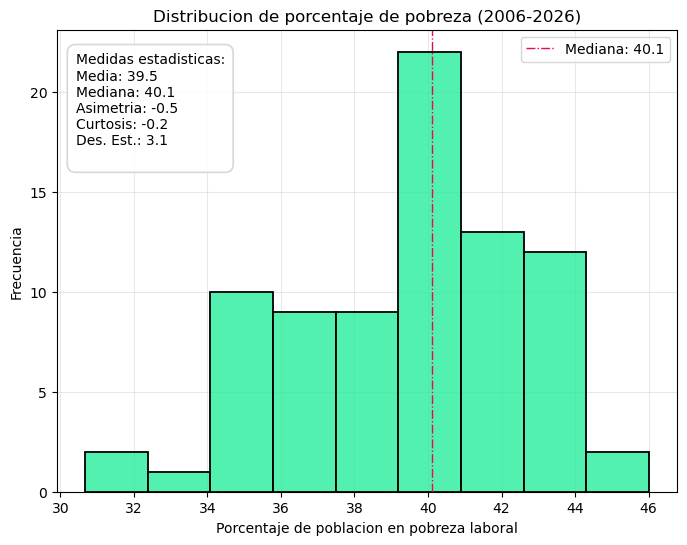

In [189]:
resumen_simetria = {
    "curtosis" : pl_calculado["PL"].kurt(),
    "asimetria": pl_calculado["PL"].skew(),
    "media": pl_calculado["PL"].mean(),
    "mediana" : pl_calculado["PL"].median(),
    "des_est" : pl_calculado["PL"].std(),
}
texto_metricas = (f"Medidas estadisticas:\n"
                  f"Media: {resumen_simetria['media']:.1f}\n"
f"Mediana: {resumen_simetria['mediana']:.1f}\n"
f"Asimetria: {resumen_simetria['asimetria']:.1f}\n"
f"Curtosis: {resumen_simetria['curtosis']:.1f}\n"
f"Des. Est.: {resumen_simetria['des_est']:.1f}\n"
                 )
propiedades = dict(
    boxstyle="round, pad=0.6",
    facecolor="white",
    edgecolor="lightgray",
    linewidth=1.2,
    alpha=0.9
)
# Crear histograma
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=pl_calculado, x="PL", bins=9, edgecolor="black", linewidth=1.3, color="#1AED95")
plt.title("Distribucion de porcentaje de pobreza (2006-2026)")
plt.xlabel("Porcentaje de poblacion en pobreza laboral")
plt.ylabel("Frecuencia")
ax.set_axisbelow(True)
ax.grid(linestyle="-", color="lightgray", linewidth=0.75, alpha=0.50)
ax.axvline(x=resumen_simetria["mediana"], color="#ED0557", linestyle="-.", linewidth=1, label=f"Mediana: {resumen_simetria['mediana']:.1f}")
ax.legend()
ax.text(
    x=0.03, y=0.95,
    s=texto_metricas,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=propiedades
)
plt.show()

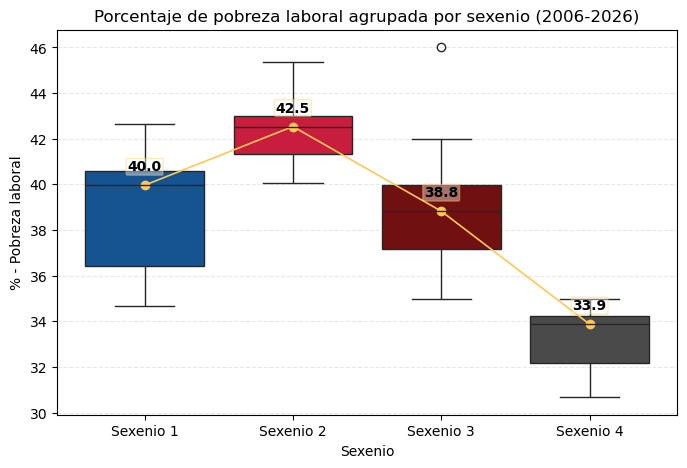

In [250]:
# Graficar la serie temporal boxplot de pobreza laboral por sexenio
# Agregar etiquetas de sexenio
df_pobrezalab = pl_calculado.copy()
def get_sexenio(año):
    for nombre, rango in sexenio_analisis.items():
        if rango[0] <= año <= rango[1]:
            return nombre
    return "Sin Nombre"
    
sexenio_analisis = {"Sexenio 1": [2006, 2012],
                   "Sexenio 2": [2013, 2018],
                   "Sexenio 3": [2019, 2024],
                   "Sexenio 4": [2025, 2026]}
df_pobrezalab["Sexenio"] = df_pobrezalab["Año"].map(get_sexenio)
medianas_agrupadas = df_pobrezalab.groupby("Sexenio")["PL"].median().reset_index()

# Creaccion del diagrama boxplot
plt.figure(figsize=(8,5))
colores = ['#0055A4', '#E4002B', '#800000', '#4A4A4A'] # Definir colores para los boxplot
sns.boxplot(data=df_pobrezalab, x='Sexenio', y='PL', hue='Sexenio', palette=colores, legend=False) # Pasar la lista al argumento 'palette'
plt.plot(range(len(medianas_agrupadas)), medianas_agrupadas['PL'], 
         color='#FFC857', marker='o', linewidth=1.2)
for i, row in medianas_agrupadas.iterrows():
    plt.text(x=i, 
             y=row['PL'] + 0.5,           # Ajustar el '+ 0.5' para subir/bajar el texto
             s=f"{row['PL']:.1f}",       # Formato del texto (1 decimal)
             bbox=dict(facecolor='white', alpha=0.4, edgecolor='#FFC857', boxstyle='round,pad=0.1'),
             ha='center', va='bottom', color='black', fontweight='bold')

plt.title("Porcentaje de pobreza laboral agrupada por sexenio (2006-2026)")
plt.xlabel("Sexenio")
plt.ylabel("% - Pobreza laboral")
plt.grid(axis='y', linestyle='--', alpha=0.5, color="lightgray")
plt.show()